# Evaluating the Impact of Image Augmentation Strategies on CNN Architectures in Skin Lesion Classification

**DS 6050, SP 2026 - ML III: Deep Learning Project** *For Professor Heman Shakeri, PhD, University of Virginia*

---

### Team Members
* **Robert Ashby** | *University of Virginia, School of Data Science* | Fernandina Beach, Florida | gsr3qz@virginia.edu
* **Xavier Colbert** | *University of Virginia, School of Data Science* | Alexandria, Virginia | kxp3jj@virginia.edu
* **Jacob Kuchta** | *University of Virginia, School of Data Science* | Arlington, Virginia | mjk3ku@virginia.edu
* **Alysa Pugmire** | *University of Virginia, School of Data Science* | Richmond, Virginia | amp3xs@virginia.edu

## Notebook 04 purpose

This notebook performs the cumulative ablation study for the skin lesion classification project.

Where `03_augmentation_experiments.ipynb` evaluated each augmentation phase independently against a same-backbone baseline, this notebook evaluates the effect of **adding augmentation phases sequentially** within each backbone.

The cumulative ablation ladder is:

1. **baseline**  
   Resize, tensor conversion, and normalization only

2. **phase1_plus_2**  
   Baseline + geometric augmentation

3. **phase1_plus_2_plus_3**  
   Baseline + geometric augmentation + color augmentation

4. **phase1_plus_2_plus_3_plus_4**  
   Baseline + geometric augmentation + color augmentation + scale/crop augmentation, with CutMix applied in the training loop

The goal is to determine whether performance improves consistently as augmentation complexity is added, and whether those effects differ across:
- ResNet-50
- EfficientNet-B0
- DenseNet-121

This notebook intentionally reuses the same core pipeline established in earlier notebooks, including:
- processed CSV loading
- path normalization
- label indexing
- class-weighted loss
- model builder imports
- dataset and dataloader structure
- evaluation with balanced accuracy and macro AUC
- saved metrics, predictions, and checkpoints

Only the experiment design changes here. The training and evaluation mechanics should remain aligned with the earlier validated notebooks.

## Experimental structure

This notebook uses a smoke-test mode before full execution.

In smoke mode:
- each backbone is run through the full cumulative ladder
- stratified train and validation subsets are used
- epoch count is reduced
- output files are still written so the end-to-end ablation pipeline can be verified

In full mode:
- the complete processed ISIC 2019 train and validation splits are used
- each backbone is run through all cumulative ablation stages
- results are saved for downstream reporting and comparison

In [20]:
SMOKE_MODE = True

ABLATION_STAGES = [
    "baseline",
    "phase1_plus_2",
    "phase1_plus_2_plus_3",
    "phase1_plus_2_plus_3_plus_4",
]

BACKBONES = [
    "resnet50",
    "efficientnet_b0",
    "densenet121",
]

SMOKE_TRAIN_FRACTION = 0.125
SMOKE_VAL_FRACTION = 0.25
SMOKE_MIN_TRAIN_PER_CLASS = 40
SMOKE_MIN_VAL_PER_CLASS = 15
SMOKE_MAX_TRAIN_PER_CLASS = 250
SMOKE_MAX_VAL_PER_CLASS = 75

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
FREEZE_FEATURES = False
SAVE_CHECKPOINTS = True

SMOKE_EPOCHS = 1
FULL_EPOCHS = 5
EPOCHS = SMOKE_EPOCHS if SMOKE_MODE else FULL_EPOCHS

EXPERIMENT_SEED = 42

## Imports and project-root setup

In [21]:
from pathlib import Path
import sys
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import transforms

from sklearn.metrics import balanced_accuracy_score, roc_auc_score, classification_report, confusion_matrix

In [22]:
# Resolve the project root, not just the current notebook directory
cwd = Path.cwd().resolve()
ROOT = cwd.parent if cwd.name.lower() == "code" else cwd
SCRIPTS = ROOT / "scripts"

if str(SCRIPTS) not in sys.path:
    sys.path.append(str(SCRIPTS))

from resnet50_baseline import build_resnet50
from efficientnet_b0_baseline import build_efficientnet_b0
from densenet121_baseline import build_densenet121

from phase2_geometric import build_phase2_transform
from phase3_color import build_phase3_transform
from phase4_scale_crop import build_phase4_transform, cutmix_data, cutmix_loss

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("CWD:", cwd)
print("ROOT:", ROOT)
print("SCRIPTS:", SCRIPTS)
print("DEVICE:", DEVICE)

CWD: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/Code
ROOT: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire
SCRIPTS: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/scripts
DEVICE: cuda


## Save experiment configuration and set seeds

In [23]:
OUT_ROOT = ROOT / "outputs"

CONFIG_DIR = OUT_ROOT / "configs" / "04_ablation_study"
FIG_DIR = OUT_ROOT / "figures" / "04_ablation_study"
METRIC_DIR = OUT_ROOT / "metrics"
PRED_DIR = OUT_ROOT / "preds"
CKPT_DIR = OUT_ROOT / "checkpoints"
REPORT_DIR = OUT_ROOT / "reports" / "04_ablation_study"

for d in [CONFIG_DIR, FIG_DIR, METRIC_DIR, PRED_DIR, CKPT_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

EXPERIMENT_CONFIG = {
    "notebook": "04_ablation_study",
    "seed": EXPERIMENT_SEED,
    "smoke_mode": SMOKE_MODE,
    "ablation_stages": ABLATION_STAGES,
    "backbones": BACKBONES,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "freeze_features": FREEZE_FEATURES,
}

config_path = CONFIG_DIR / ("smoke_config.json" if SMOKE_MODE else "full_config.json")

with open(config_path, "w") as f:
    json.dump(EXPERIMENT_CONFIG, f, indent=2)

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(EXPERIMENT_SEED)

loader_generator = torch.Generator()
loader_generator.manual_seed(EXPERIMENT_SEED)

print("Saved config to:", config_path)
print("Global seed set.")
print("DataLoader generator seeded.")

Saved config to: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/configs/04_ablation_study/smoke_config.json
Global seed set.
DataLoader generator seeded.


## Locate and load processed ISIC 2019 splits

In [24]:
DATA = ROOT / "DATA"
PROCESSED = DATA / "processed"

train_csv = PROCESSED / "isic2019" / "train.csv"
val_csv = PROCESSED / "isic2019" / "val.csv"
weights_json = PROCESSED / "class_weights.json"

print("train_csv exists:", train_csv.exists())
print("val_csv exists:", val_csv.exists())
print("weights_json exists:", weights_json.exists())

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)

def normalize_path_column(df, col):
    df = df.copy()
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace("\\", "/", regex=False)
    return df

train_df = normalize_path_column(train_df, "image_path")
val_df = normalize_path_column(val_df, "image_path")

required_cols = ["image_path", "label"]
for col in required_cols:
    if col not in train_df.columns:
        raise ValueError(f"Missing required column in train_df: {col}")
    if col not in val_df.columns:
        raise ValueError(f"Missing required column in val_df: {col}")

print("train_df shape:", train_df.shape)
print("val_df shape:", val_df.shape)
print("\ntrain_df columns:")
print(train_df.columns.tolist())

train_csv exists: True
val_csv exists: True
weights_json exists: True
train_df shape: (21531, 21)
val_df shape: (3800, 21)

train_df columns:
['image_id', 'label', 'age_approx', 'anatom_site_general', 'lesion_id', 'sex', 'is_malignant', 'image_path', 'age_scaled', 'sex_female', 'sex_male', 'sex_unknown', 'anatom_site_general_anterior torso', 'anatom_site_general_head/neck', 'anatom_site_general_lateral torso', 'anatom_site_general_lower extremity', 'anatom_site_general_oral/genital', 'anatom_site_general_palms/soles', 'anatom_site_general_posterior torso', 'anatom_site_general_unknown', 'anatom_site_general_upper extremity']


## Encode labels and class weights

In [25]:
labels = sorted(train_df["label"].unique())
label_to_idx = {label: idx for idx, label in enumerate(labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

train_df["label_idx"] = train_df["label"].map(label_to_idx)
val_df["label_idx"] = val_df["label"].map(label_to_idx)

with open(weights_json, "r") as f:
    class_weights_dict = json.load(f)

class_weight_tensor = torch.tensor(
    [class_weights_dict[label] for label in labels],
    dtype=torch.float32,
    device=DEVICE,
)

print("Labels:", labels)
print("label_to_idx:", label_to_idx)
print("Class weights tensor:", class_weight_tensor)

Labels: ['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']
label_to_idx: {'AK': 0, 'BCC': 1, 'BKL': 2, 'DF': 3, 'MEL': 4, 'NV': 5, 'SCC': 6, 'VASC': 7}
Class weights tensor: tensor([ 3.6518,  0.9530,  1.2069, 13.2580,  0.7001,  0.2459,  5.0400, 12.5180],
       device='cuda:0')


## Build stratified smoke-test subsets

In [26]:
def make_stratified_smoke_subset(
    df: pd.DataFrame,
    label_col: str,
    frac: float,
    min_per_class: int,
    max_per_class: int,
    seed: int = 42,
) -> pd.DataFrame:
    parts = []
    for _, group in df.groupby(label_col):
        n_total = len(group)
        n_take = max(min_per_class, int(round(n_total * frac)))
        n_take = min(n_take, max_per_class, n_total)
        sampled = group.sample(n=n_take, random_state=seed)
        parts.append(sampled)

    out = (
        pd.concat(parts, axis=0)
        .sample(frac=1.0, random_state=seed)
        .reset_index(drop=True)
    )
    return out

if SMOKE_MODE:
    train_run_df = make_stratified_smoke_subset(
        train_df,
        label_col="label",
        frac=SMOKE_TRAIN_FRACTION,
        min_per_class=SMOKE_MIN_TRAIN_PER_CLASS,
        max_per_class=SMOKE_MAX_TRAIN_PER_CLASS,
        seed=EXPERIMENT_SEED,
    )
    val_run_df = make_stratified_smoke_subset(
        val_df,
        label_col="label",
        frac=SMOKE_VAL_FRACTION,
        min_per_class=SMOKE_MIN_VAL_PER_CLASS,
        max_per_class=SMOKE_MAX_VAL_PER_CLASS,
        seed=EXPERIMENT_SEED,
    )
else:
    train_run_df = train_df.copy()
    val_run_df = val_df.copy()

print("train_run_df shape:", train_run_df.shape)
print("val_run_df shape:", val_run_df.shape)

print("\ntrain_run_df class counts:")
print(train_run_df["label"].value_counts().sort_index())

print("\nval_run_df class counts:")
print(val_run_df["label"].value_counts().sort_index())

train_run_df shape: (1239, 22)
val_run_df shape: (386, 22)

train_run_df class counts:
label
AK       92
BCC     250
BKL     250
DF       40
MEL     250
NV      250
SCC      67
VASC     40
Name: count, dtype: int64

val_run_df class counts:
label
AK      32
BCC     75
BKL     75
DF      15
MEL     75
NV      75
SCC     24
VASC    15
Name: count, dtype: int64


## Dataset and transforms

In [27]:
class ISICDataset(Dataset):
    def __init__(self, df, root, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.root = Path(root)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        rel_path = str(row["image_path"]).replace("\\", "/")
        image = Image.open(self.root / rel_path).convert("RGB")
        label = int(row["label_idx"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label, rel_path

In [28]:
def make_baseline_transforms(image_size=224):
    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

    train_tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        normalize,
    ])

    val_tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        normalize,
    ])

    return train_tf, val_tf

In [29]:
def make_phase2_transform(image_size=224):
    base_ops = [
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ]
    return build_phase2_transform(
        base_ops=base_ops,
        mode="random",
    )

def make_phase3_transform(image_size=224):
    base_ops = [
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ]
    return build_phase3_transform(
        base_ops=base_ops,
        brightness=0.2,
        contrast=0.2,
        hue=0.1,
        saturation=0.2,
    )

def make_phase4_transform(image_size=224):
    base_ops = [
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ]
    return build_phase4_transform(
        base_ops=base_ops,
        size=image_size,
        scale=(0.7, 1.0),
        ratio=(3/4, 4/3),
    )

In [30]:
baseline_train_tf, val_tf = make_baseline_transforms(IMAGE_SIZE)
phase2_tf = make_phase2_transform(IMAGE_SIZE)
phase3_tf = make_phase3_transform(IMAGE_SIZE)
phase4_tf = make_phase4_transform(IMAGE_SIZE)

sample_baseline_ds = ISICDataset(train_run_df, ROOT, transform=baseline_train_tf)
sample_img, sample_label, sample_path = sample_baseline_ds[0]

print("Sample baseline tensor shape:", sample_img.shape)
print("Sample baseline label index:", sample_label)
print("Sample baseline label name:", idx_to_label[sample_label])
print("Sample baseline path:", sample_path)

Sample baseline tensor shape: torch.Size([3, 224, 224])
Sample baseline label index: 2
Sample baseline label name: BKL
Sample baseline path: DATA/isic2019/train/images/ISIC_2019_Training_Input/ISIC_0026290.jpg


## Cumulative ablation dataset construction

To stay aligned with the design established in Notebook 03, cumulative ablation stages are implemented by concatenating the original training dataset with stage-specific augmented copies.

This keeps the baseline training examples present at every stage while adding progressively richer augmentation variants.

In [31]:
def make_stage_datasets(stage_name):
    baseline_ds = ISICDataset(train_run_df, ROOT, transform=baseline_train_tf)

    if stage_name == "baseline":
        train_ds = baseline_ds
        use_cutmix = False
        component_names = ["baseline"]
        component_sizes = [len(baseline_ds)]
        return train_ds, use_cutmix, component_names, component_sizes

    datasets = [baseline_ds]
    component_names = ["baseline"]
    component_sizes = [len(baseline_ds)]
    use_cutmix = False

    if stage_name in ["phase1_plus_2", "phase1_plus_2_plus_3", "phase1_plus_2_plus_3_plus_4"]:
        ds_phase2 = ISICDataset(train_run_df, ROOT, transform=phase2_tf)
        datasets.append(ds_phase2)
        component_names.append("phase2")
        component_sizes.append(len(ds_phase2))

    if stage_name in ["phase1_plus_2_plus_3", "phase1_plus_2_plus_3_plus_4"]:
        ds_phase3 = ISICDataset(train_run_df, ROOT, transform=phase3_tf)
        datasets.append(ds_phase3)
        component_names.append("phase3")
        component_sizes.append(len(ds_phase3))

    if stage_name == "phase1_plus_2_plus_3_plus_4":
        ds_phase4 = ISICDataset(train_run_df, ROOT, transform=phase4_tf)
        datasets.append(ds_phase4)
        component_names.append("phase4")
        component_sizes.append(len(ds_phase4))
        use_cutmix = True

    train_ds = ConcatDataset(datasets)
    return train_ds, use_cutmix, component_names, component_sizes

In [32]:
def make_stage_loaders(stage_name):
    train_ds, use_cutmix, component_names, component_sizes = make_stage_datasets(stage_name)

    val_ds = ISICDataset(val_run_df, ROOT, transform=val_tf)

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        generator=loader_generator,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    return train_ds, val_ds, train_loader, val_loader, use_cutmix, component_names, component_sizes

## Training and evaluation utilities

In [33]:
def maybe_apply_cutmix(x, y, cutmix_prob=0.5, alpha=1.0):
    if alpha <= 0:
        return x, y, y, 1.0
    if np.random.rand() > cutmix_prob:
        return x, y, y, 1.0
    return cutmix_data(x, y, alpha=alpha)

In [34]:
def train_one_epoch(model, loader, criterion, optimizer, device, use_cutmix=False):
    model.train()
    running_loss = 0.0
    n_samples = 0

    for images, targets, _ in loader:
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        if use_cutmix:
            images, y_a, y_b, lam = maybe_apply_cutmix(
                images, targets, cutmix_prob=0.5, alpha=1.0
            )
            logits = model(images)
            loss = cutmix_loss(criterion, logits, y_a, y_b, lam)
        else:
            logits = model(images)
            loss = criterion(logits, targets)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        n_samples += batch_size

    return running_loss / max(n_samples, 1)

In [35]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    n_samples = 0

    all_targets = []
    all_preds = []
    all_probs = []
    all_paths = []

    for images, targets, paths in loader:
        images = images.to(device)
        targets = targets.to(device)

        logits = model(images)
        loss = criterion(logits, targets)

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        n_samples += batch_size

        all_targets.extend(targets.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_paths.extend(paths)

    avg_loss = running_loss / max(n_samples, 1)
    y_true = np.array(all_targets)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    bal_acc = balanced_accuracy_score(y_true, y_pred)

    try:
        macro_auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    except ValueError:
        macro_auc = np.nan

    preds_df = pd.DataFrame({
        "rel_path": all_paths,
        "y_true_idx": y_true,
        "y_pred_idx": y_pred,
        "y_true_label": [idx_to_label[i] for i in y_true],
        "y_pred_label": [idx_to_label[i] for i in y_pred],
    })

    cm_counts = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))))
    cm_row_norm = confusion_matrix(
        y_true, y_pred, labels=list(range(len(labels))), normalize="true"
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=list(range(len(labels))),
        target_names=labels,
        output_dict=True,
        zero_division=0,
    )

    return {
        "loss": avg_loss,
        "balanced_accuracy": bal_acc,
        "macro_auc": macro_auc,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "paths": all_paths,
        "preds_df": preds_df,
        "cm_counts": cm_counts,
        "cm_row_norm": cm_row_norm,
        "classification_report": report_dict,
    }

## Model builders

In [36]:
MODEL_BUILDERS = {
    "resnet50": build_resnet50,
    "efficientnet_b0": build_efficientnet_b0,
    "densenet121": build_densenet121,
}

## Plotting helpers

In [37]:
def plot_history(history_df, backbone, stage_name, fig_dir):
    tag = f"{backbone}_{stage_name}"

    plt.figure(figsize=(8, 4))
    plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{tag} loss history")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(fig_dir / f"{tag}_loss_history.png", dpi=200, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history_df["epoch"], history_df["val_balanced_accuracy"], marker="o", label="Val balanced accuracy")
    plt.plot(history_df["epoch"], history_df["val_macro_auc"], marker="o", label="Val macro AUC")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    plt.title(f"{tag} validation metrics")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(fig_dir / f"{tag}_val_metrics_history.png", dpi=200, bbox_inches="tight")
    plt.show()

In [38]:
def plot_confusion_matrices(cm_counts, cm_row_norm, backbone, stage_name, fig_dir):
    tag = f"{backbone}_{stage_name}"

    plt.figure(figsize=(8, 6))
    plt.imshow(cm_counts, interpolation="nearest")
    plt.title(f"{tag} confusion matrix (counts)")
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45, ha="right")
    plt.yticks(tick_marks, labels)

    for i in range(cm_counts.shape[0]):
        for j in range(cm_counts.shape[1]):
            plt.text(j, i, str(cm_counts[i, j]), ha="center", va="center", fontsize=8)

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig(fig_dir / f"{tag}_confusion_matrix_counts.png", dpi=200, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.imshow(cm_row_norm, interpolation="nearest", vmin=0, vmax=1)
    plt.title(f"{tag} confusion matrix (row-normalized)")
    plt.colorbar()
    plt.xticks(tick_marks, labels, rotation=45, ha="right")
    plt.yticks(tick_marks, labels)

    for i in range(cm_row_norm.shape[0]):
        for j in range(cm_row_norm.shape[1]):
            plt.text(j, i, f"{cm_row_norm[i, j]:.2f}", ha="center", va="center", fontsize=8)

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig(fig_dir / f"{tag}_confusion_matrix_row_norm.png", dpi=200, bbox_inches="tight")
    plt.show()

## Experiment runner

In [39]:
def run_ablation_experiment(backbone, stage_name):
    print("=" * 90)
    print(f"Running backbone={backbone}, stage={stage_name}")
    print("=" * 90)

    train_ds, val_ds, train_loader, val_loader, use_cutmix, component_names, component_sizes = make_stage_loaders(stage_name)

    print("Training components:")
    for name, size in zip(component_names, component_sizes):
        print(f"  {name}: {size}")
    print("Combined train size:", len(train_ds))
    print("Validation size:", len(val_ds))
    print("Use CutMix:", use_cutmix)

    build_fn = MODEL_BUILDERS[backbone]
    model = build_fn(
        num_classes=len(labels),
        pretrained=True,
        freeze_backbone=FREEZE_FEATURES,
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    history = {
        "epoch": [],
        "epoch_seconds": [],
        "train_loss": [],
        "val_loss": [],
        "val_balanced_accuracy": [],
        "val_macro_auc": [],
    }

    best_score = -np.inf
    tag = f"{backbone}_{stage_name}"
    best_ckpt_path = CKPT_DIR / f"{tag}_best.pt"
    history_path = METRIC_DIR / f"{tag}_history.csv"
    pred_path = PRED_DIR / f"{tag}_predictions.csv"
    report_path = REPORT_DIR / f"{tag}_classification_report.json"

    best_preds_df = None
    best_cm_counts = None
    best_cm_row_norm = None
    best_report_dict = None
    best_epoch = None
    best_val_loss = None
    best_val_bal_acc = None
    best_val_macro_auc = None

    for epoch in range(1, EPOCHS + 1):
        epoch_start = time.time()

        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE,
            use_cutmix=use_cutmix,
        )

        val_metrics = evaluate(model, val_loader, criterion, DEVICE)
        epoch_seconds = time.time() - epoch_start

        current_score = val_metrics["macro_auc"]
        if np.isnan(current_score):
            current_score = val_metrics["balanced_accuracy"]

        if current_score > best_score:
            best_score = current_score
            best_preds_df = val_metrics["preds_df"].copy()
            best_cm_counts = val_metrics["cm_counts"].copy()
            best_cm_row_norm = val_metrics["cm_row_norm"].copy()
            best_report_dict = val_metrics["classification_report"].copy()
            best_epoch = epoch
            best_val_loss = float(val_metrics["loss"])
            best_val_bal_acc = float(val_metrics["balanced_accuracy"])
            best_val_macro_auc = float(val_metrics["macro_auc"])

            if SAVE_CHECKPOINTS:
                torch.save(
                    {
                        "epoch": epoch,
                        "model_state_dict": model.state_dict(),
                        "label_to_idx": label_to_idx,
                        "backbone": backbone,
                        "stage_name": stage_name,
                        "image_size": IMAGE_SIZE,
                    },
                    best_ckpt_path,
                )

        history["epoch"].append(epoch)
        history["epoch_seconds"].append(epoch_seconds)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_balanced_accuracy"].append(val_metrics["balanced_accuracy"])
        history["val_macro_auc"].append(val_metrics["macro_auc"])

        print(
            f"{backbone} | {stage_name} | Epoch {epoch:02d} | "
            f"train_size={len(train_ds)} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_bal_acc={val_metrics['balanced_accuracy']:.4f} | "
            f"val_macro_auc={val_metrics['macro_auc']:.4f} | "
            f"epoch_time={epoch_seconds/60:.2f} min"
        )

    history_df = pd.DataFrame(history)
    history_df.to_csv(history_path, index=False)

    if best_preds_df is not None:
        best_preds_df.to_csv(pred_path, index=False)

    if best_report_dict is not None:
        with open(report_path, "w") as f:
            json.dump(best_report_dict, f, indent=2)

    plot_history(history_df, backbone, stage_name, FIG_DIR)

    if best_cm_counts is not None and best_cm_row_norm is not None:
        plot_confusion_matrices(best_cm_counts, best_cm_row_norm, backbone, stage_name, FIG_DIR)

    result = {
        "backbone": backbone,
        "stage": stage_name,
        "combined_train_size": len(train_ds),
        "val_size": len(val_ds),
        "use_cutmix": use_cutmix,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_balanced_accuracy": best_val_bal_acc,
        "best_val_macro_auc": best_val_macro_auc,
        "history_path": str(history_path),
        "pred_path": str(pred_path),
        "report_path": str(report_path),
        "checkpoint_path": str(best_ckpt_path),
    }

    return result

## Run cumulative ablation experiments

Running backbone=resnet50, stage=baseline
Training components:
  baseline: 1239
Combined train size: 1239
Validation size: 386
Use CutMix: False
resnet50 | baseline | Epoch 01 | train_size=1239 | train_loss=1.9507 | val_loss=1.7456 | val_bal_acc=0.3192 | val_macro_auc=0.7241 | epoch_time=0.49 min


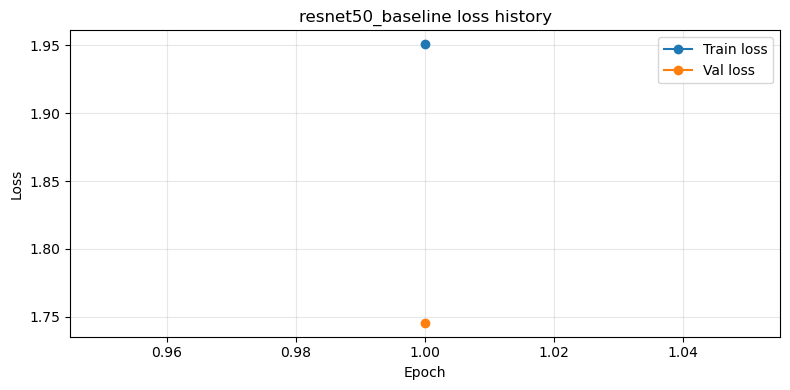

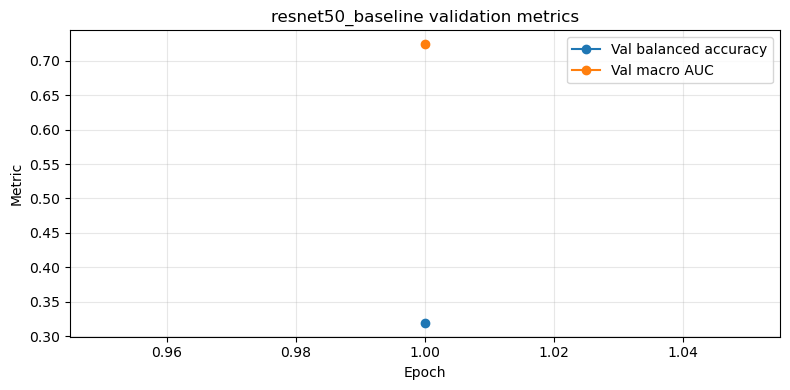

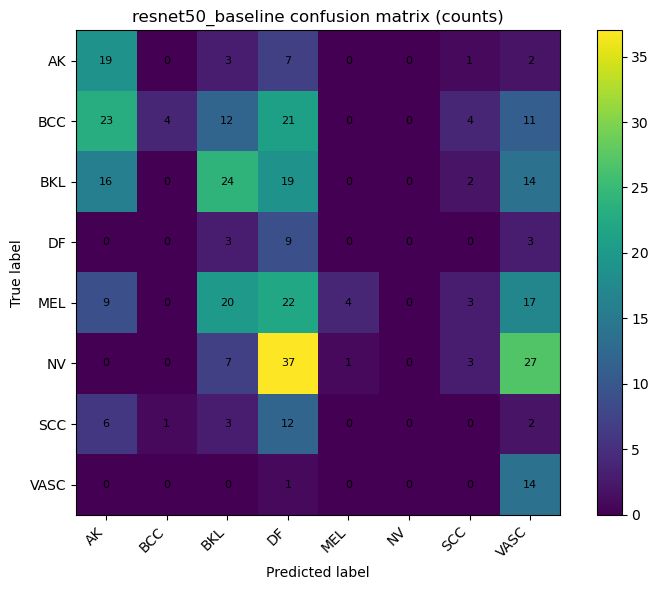

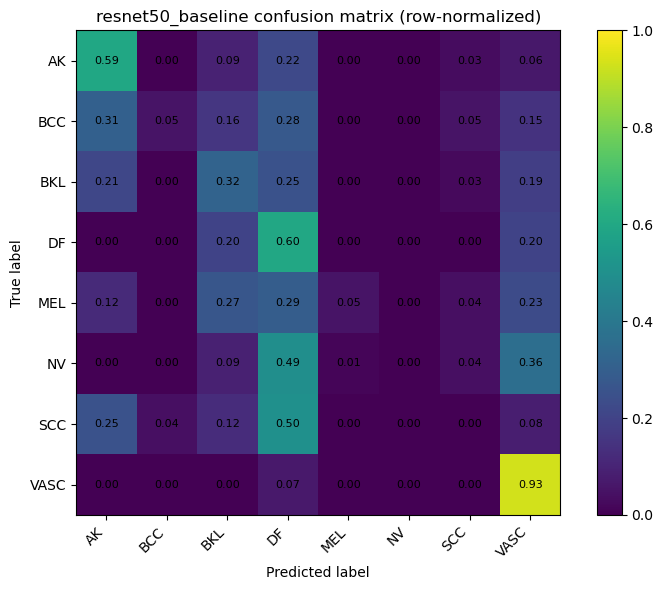

Running backbone=resnet50, stage=phase1_plus_2
Training components:
  baseline: 1239
  phase2: 1239
Combined train size: 2478
Validation size: 386
Use CutMix: False
resnet50 | phase1_plus_2 | Epoch 01 | train_size=2478 | train_loss=1.6900 | val_loss=1.4250 | val_bal_acc=0.4111 | val_macro_auc=0.7947 | epoch_time=0.82 min


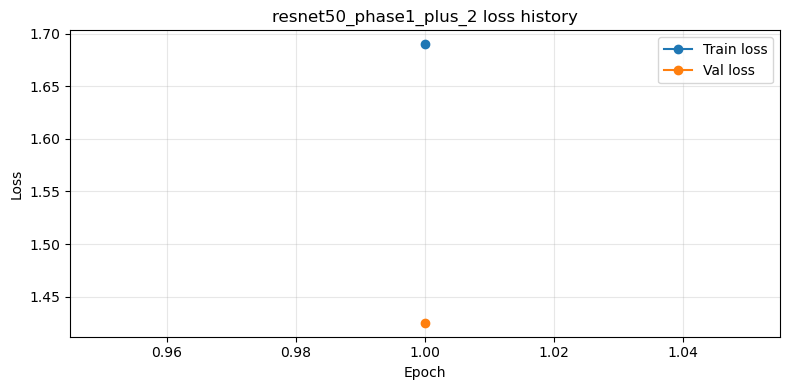

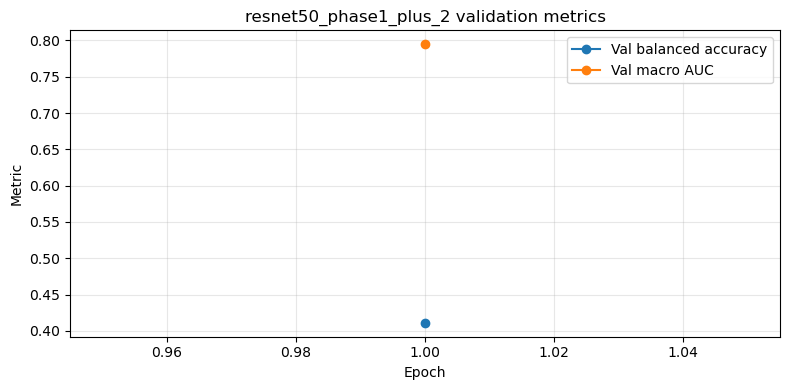

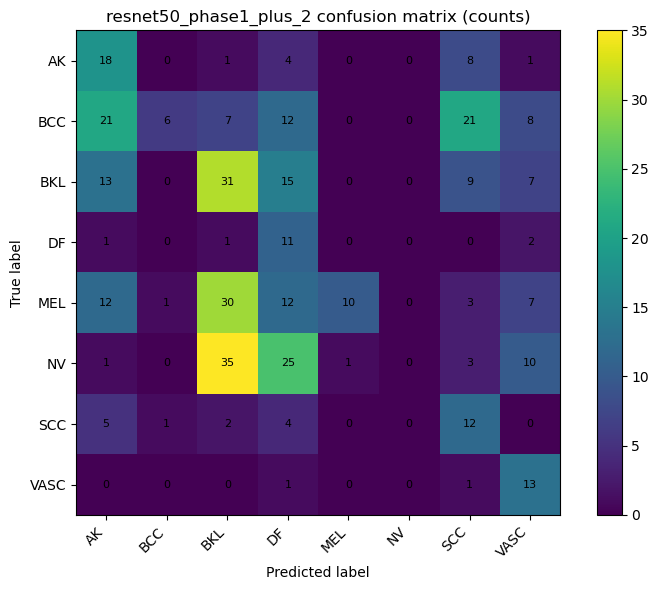

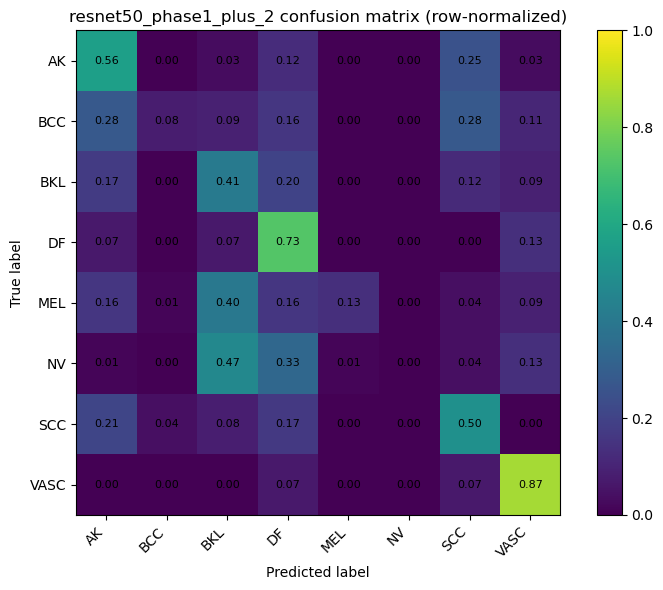

Running backbone=resnet50, stage=phase1_plus_2_plus_3
Training components:
  baseline: 1239
  phase2: 1239
  phase3: 1239
Combined train size: 3717
Validation size: 386
Use CutMix: False
resnet50 | phase1_plus_2_plus_3 | Epoch 01 | train_size=3717 | train_loss=1.6085 | val_loss=1.3016 | val_bal_acc=0.4636 | val_macro_auc=0.8436 | epoch_time=1.17 min


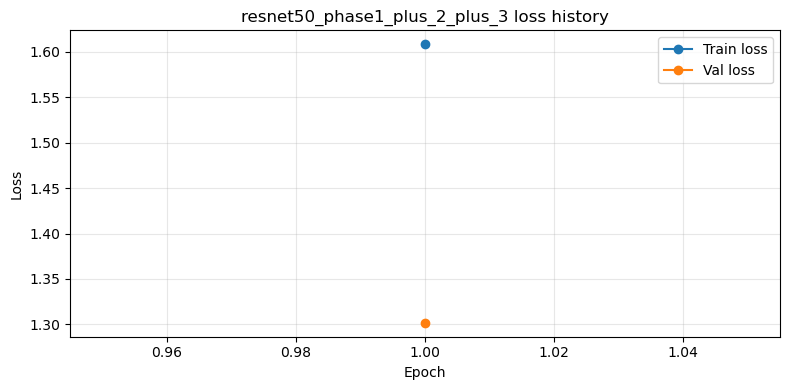

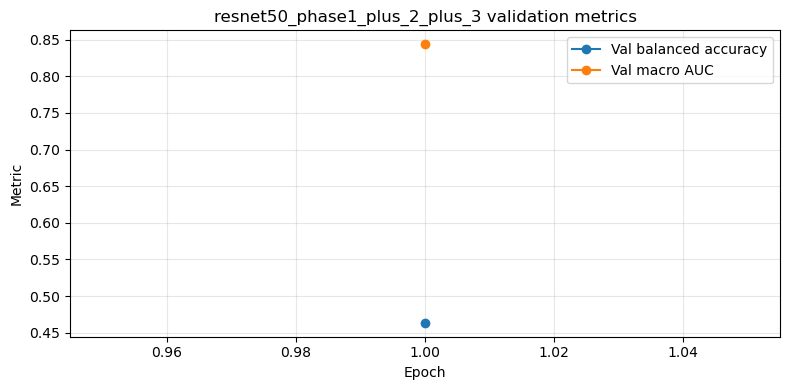

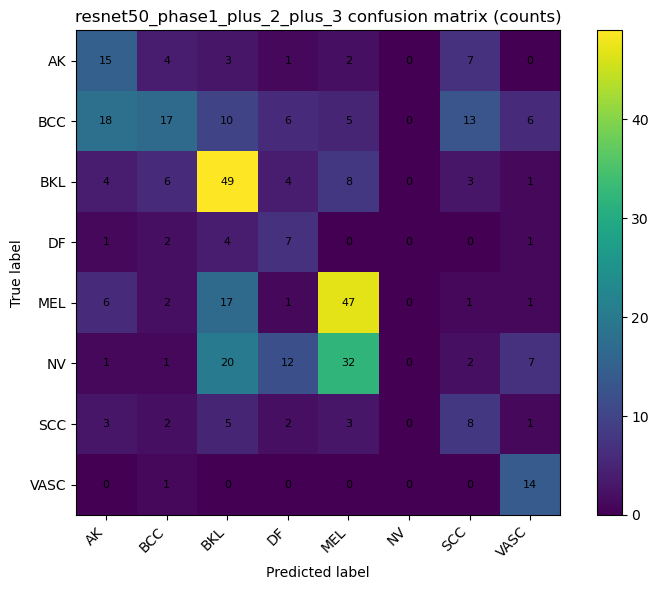

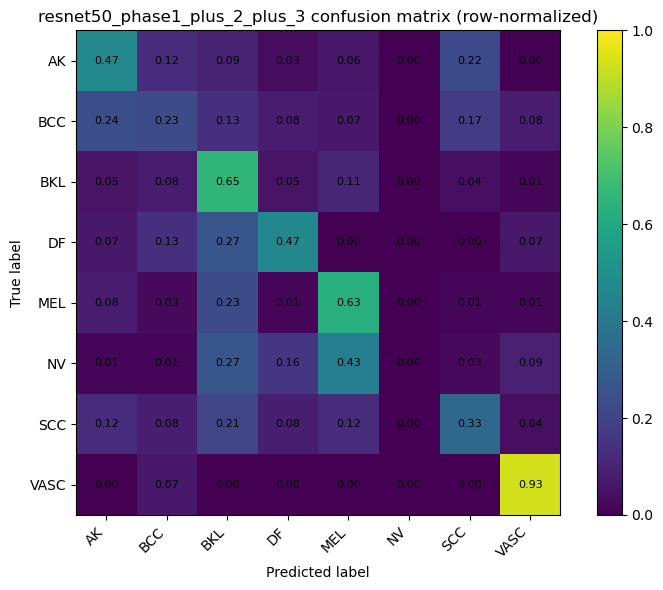

Running backbone=resnet50, stage=phase1_plus_2_plus_3_plus_4
Training components:
  baseline: 1239
  phase2: 1239
  phase3: 1239
  phase4: 1239
Combined train size: 4956
Validation size: 386
Use CutMix: True
resnet50 | phase1_plus_2_plus_3_plus_4 | Epoch 01 | train_size=4956 | train_loss=1.6166 | val_loss=1.3269 | val_bal_acc=0.4417 | val_macro_auc=0.8176 | epoch_time=1.52 min


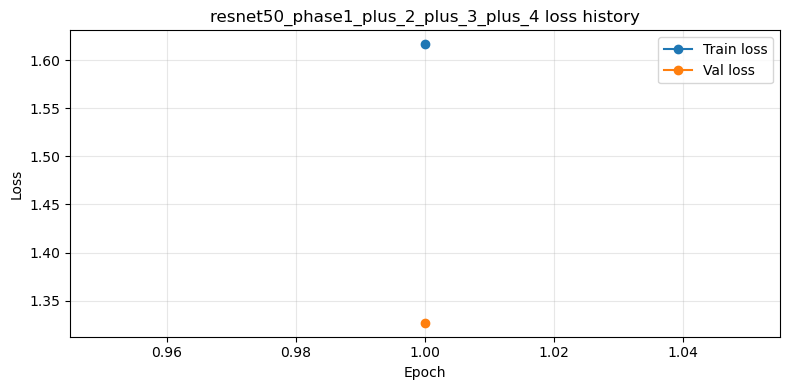

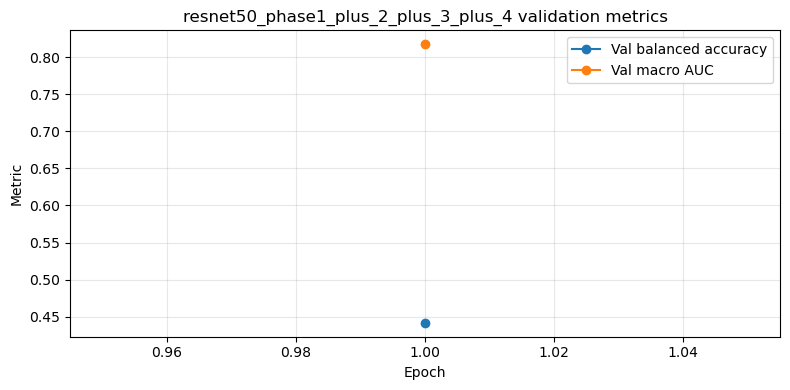

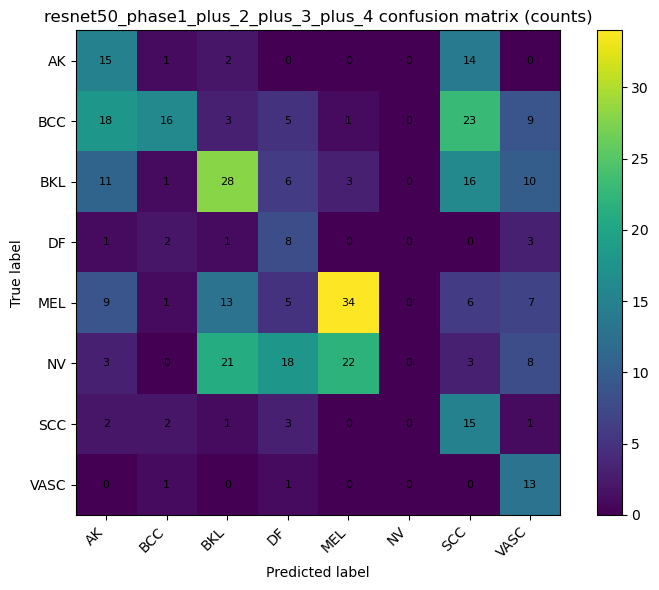

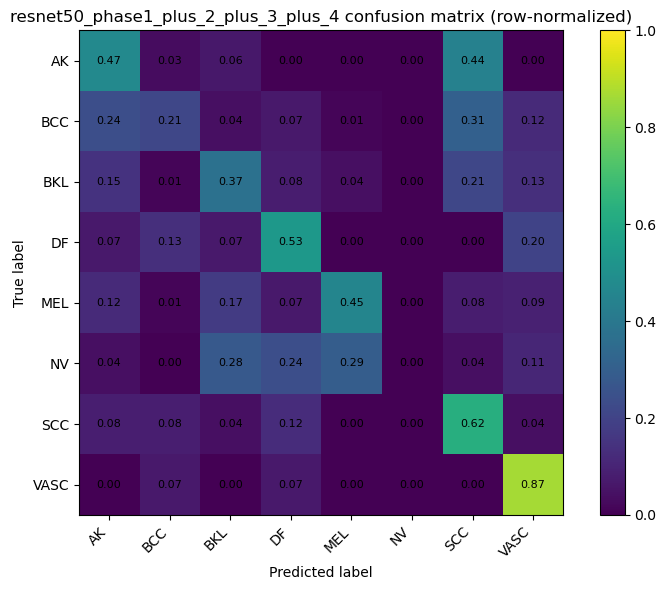

Running backbone=efficientnet_b0, stage=baseline
Training components:
  baseline: 1239
Combined train size: 1239
Validation size: 386
Use CutMix: False
efficientnet_b0 | baseline | Epoch 01 | train_size=1239 | train_loss=1.9796 | val_loss=1.7815 | val_bal_acc=0.3682 | val_macro_auc=0.7414 | epoch_time=0.42 min


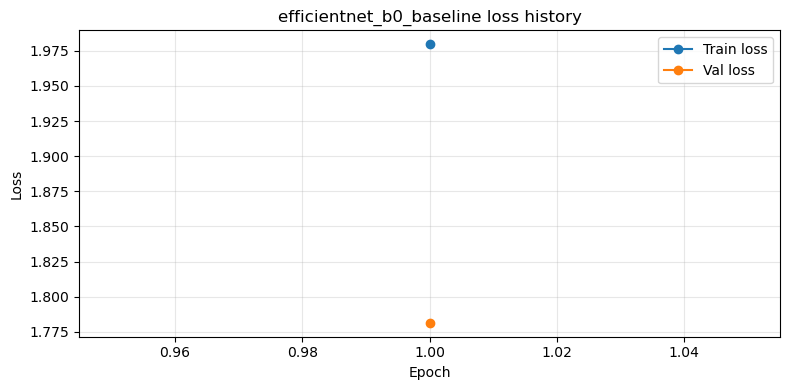

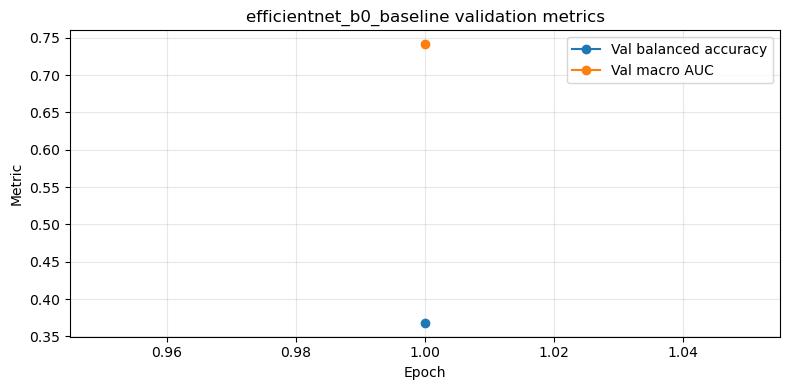

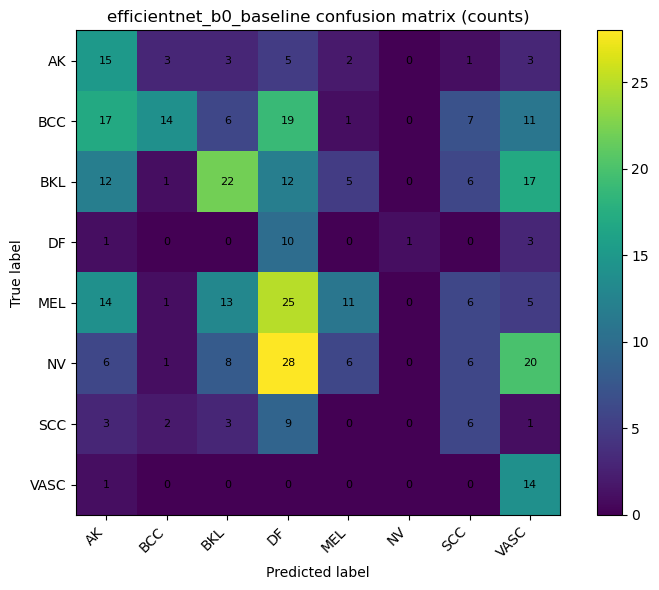

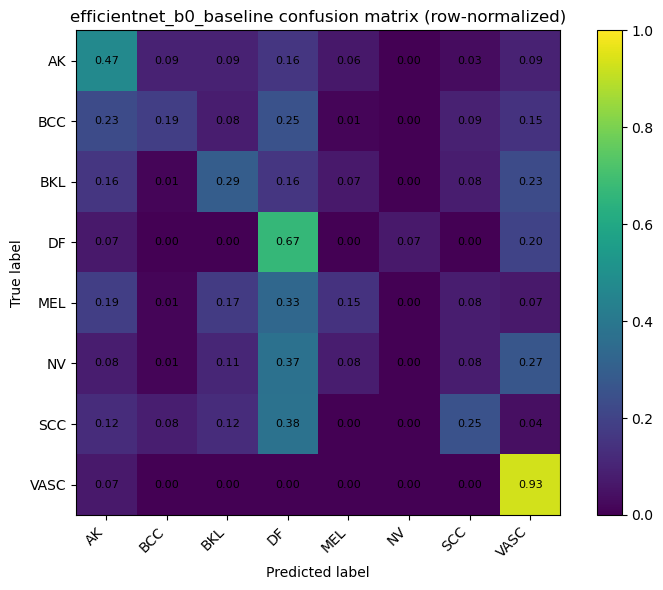

Running backbone=efficientnet_b0, stage=phase1_plus_2
Training components:
  baseline: 1239
  phase2: 1239
Combined train size: 2478
Validation size: 386
Use CutMix: False
efficientnet_b0 | phase1_plus_2 | Epoch 01 | train_size=2478 | train_loss=1.8244 | val_loss=1.5262 | val_bal_acc=0.3821 | val_macro_auc=0.7828 | epoch_time=0.77 min


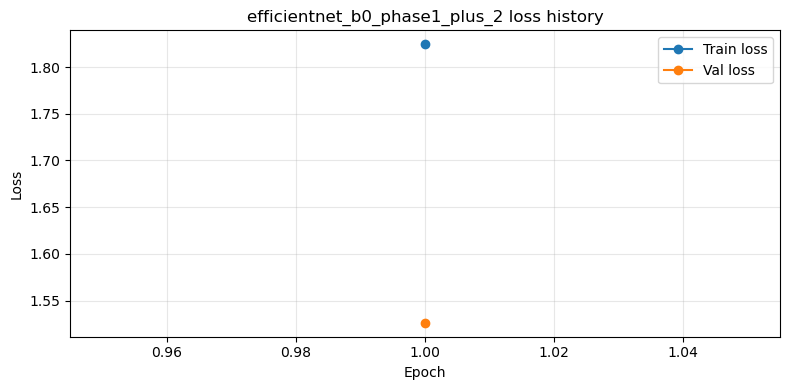

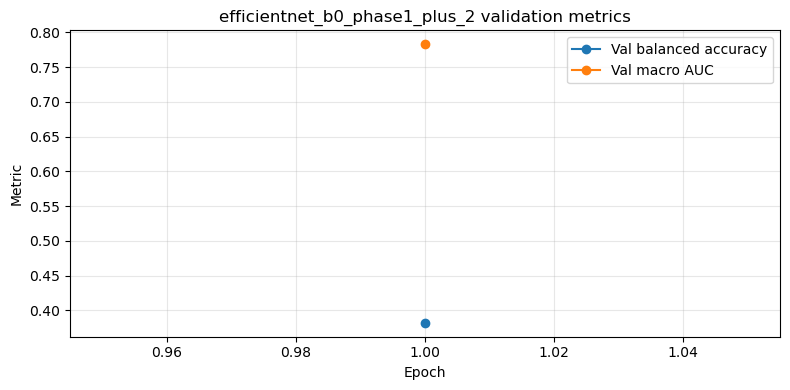

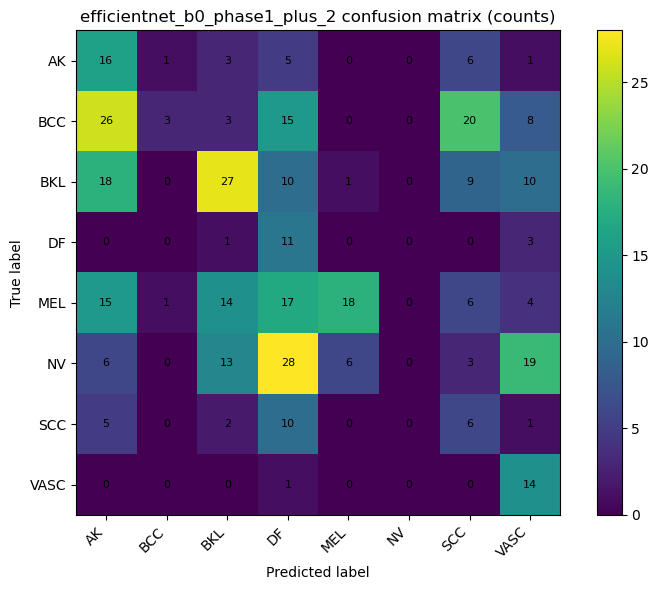

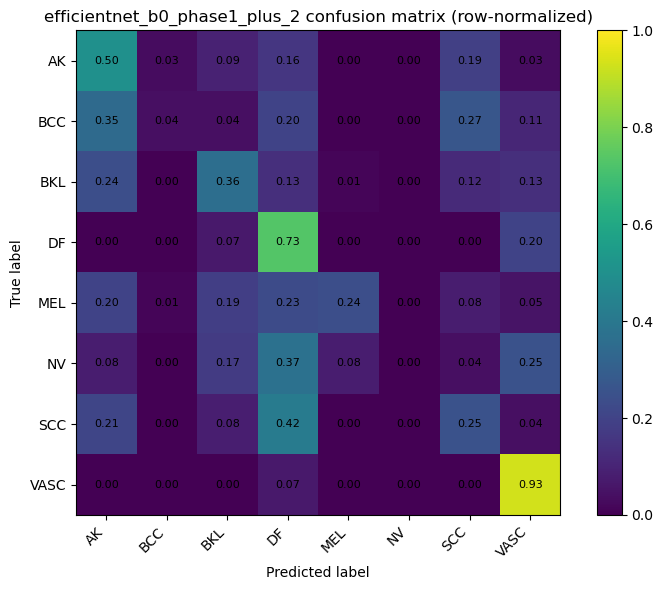

Running backbone=efficientnet_b0, stage=phase1_plus_2_plus_3
Training components:
  baseline: 1239
  phase2: 1239
  phase3: 1239
Combined train size: 3717
Validation size: 386
Use CutMix: False
efficientnet_b0 | phase1_plus_2_plus_3 | Epoch 01 | train_size=3717 | train_loss=1.7678 | val_loss=1.3690 | val_bal_acc=0.3886 | val_macro_auc=0.8052 | epoch_time=1.13 min


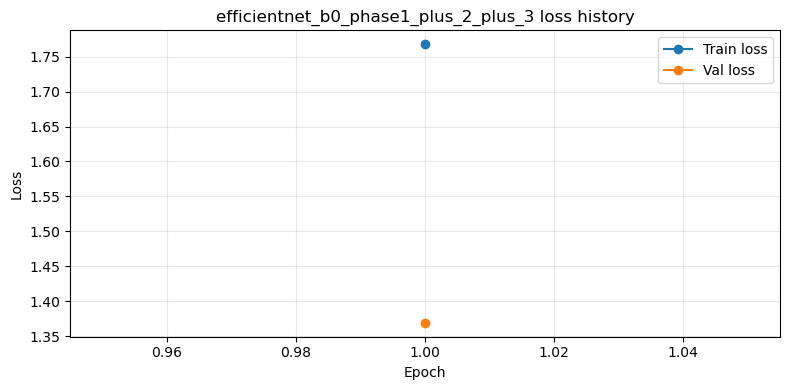

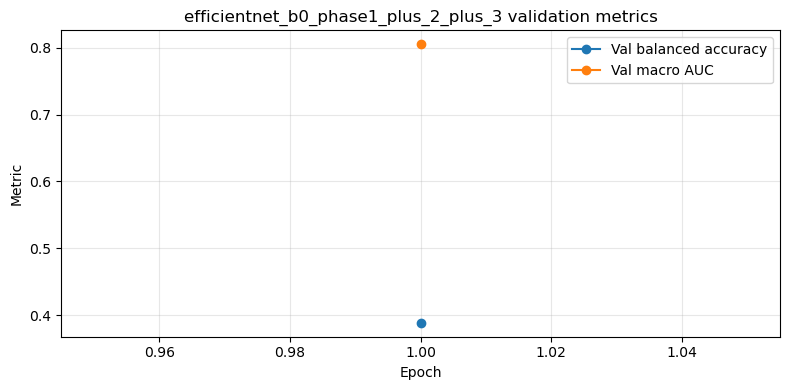

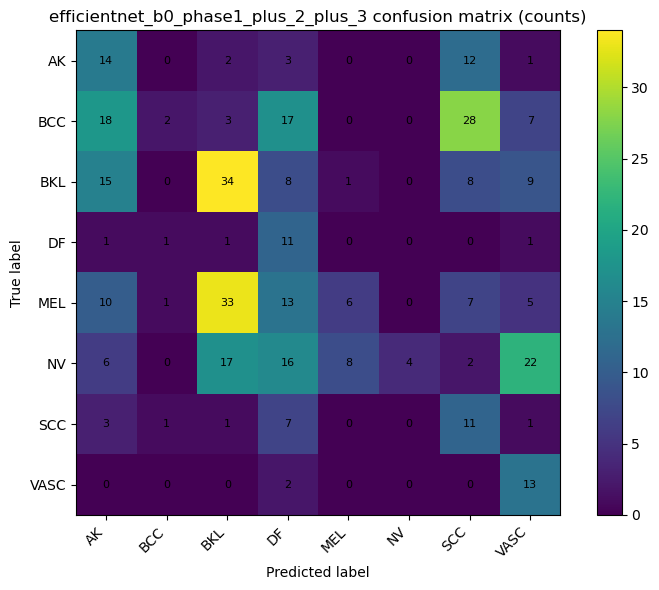

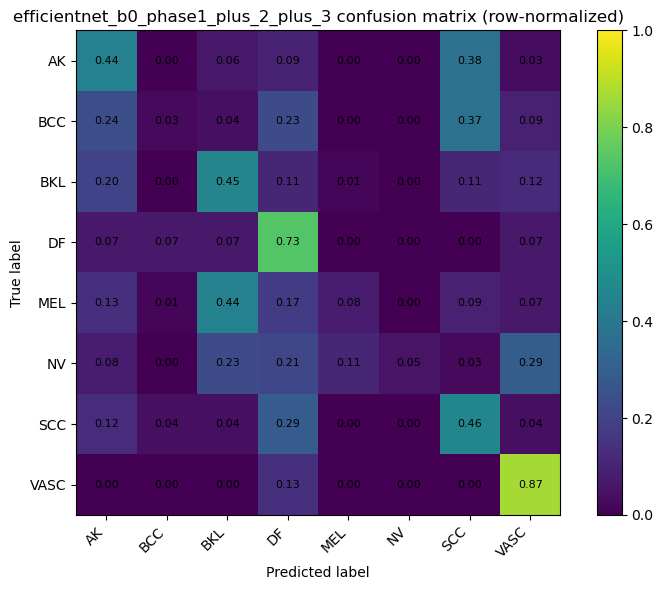

Running backbone=efficientnet_b0, stage=phase1_plus_2_plus_3_plus_4
Training components:
  baseline: 1239
  phase2: 1239
  phase3: 1239
  phase4: 1239
Combined train size: 4956
Validation size: 386
Use CutMix: True
efficientnet_b0 | phase1_plus_2_plus_3_plus_4 | Epoch 01 | train_size=4956 | train_loss=1.7307 | val_loss=1.2732 | val_bal_acc=0.4192 | val_macro_auc=0.8234 | epoch_time=1.46 min


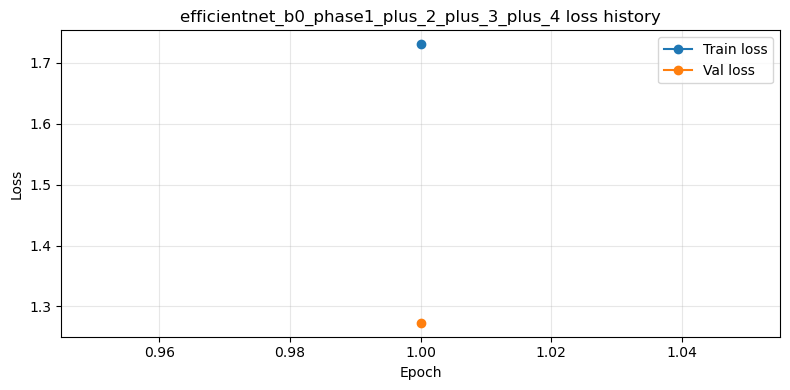

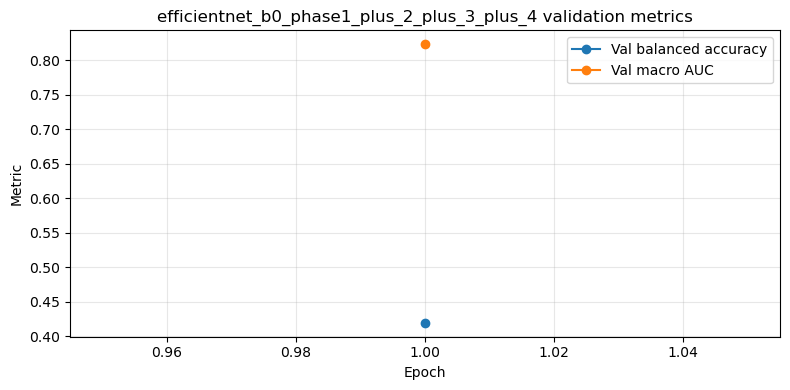

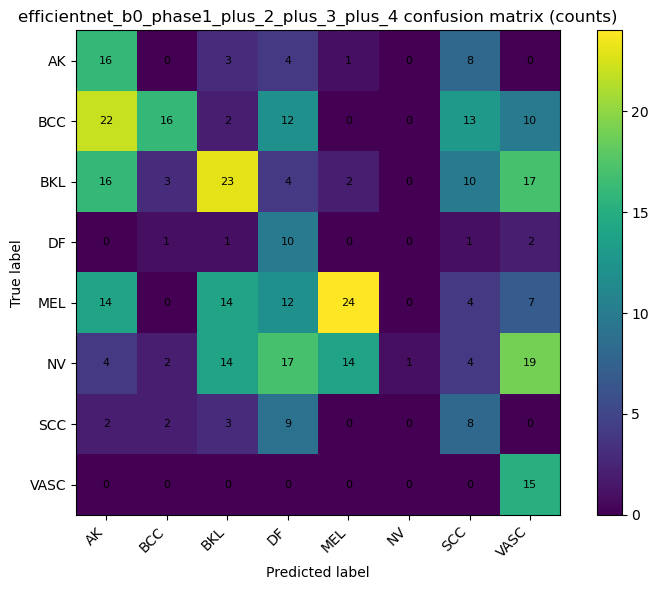

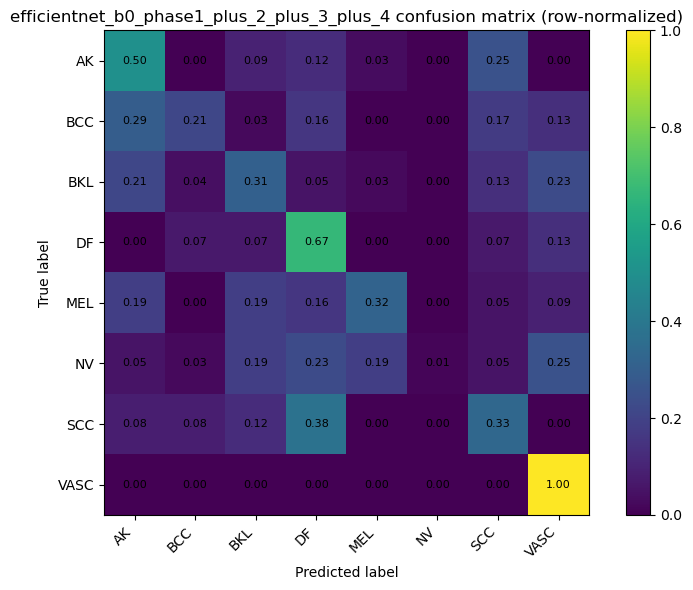

Running backbone=densenet121, stage=baseline
Training components:
  baseline: 1239
Combined train size: 1239
Validation size: 386
Use CutMix: False
densenet121 | baseline | Epoch 01 | train_size=1239 | train_loss=1.7807 | val_loss=1.3672 | val_bal_acc=0.3948 | val_macro_auc=0.8134 | epoch_time=0.46 min


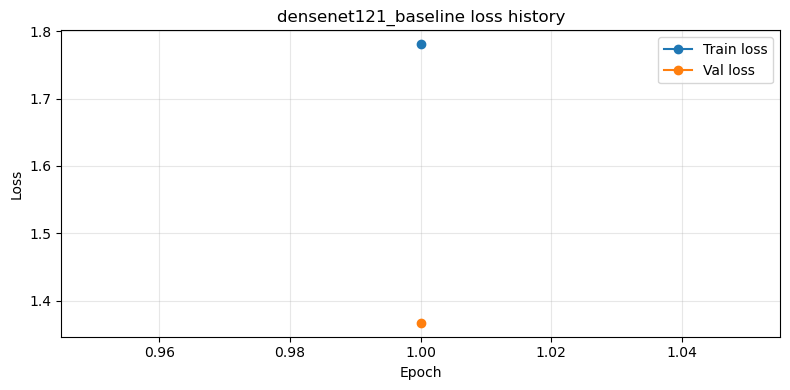

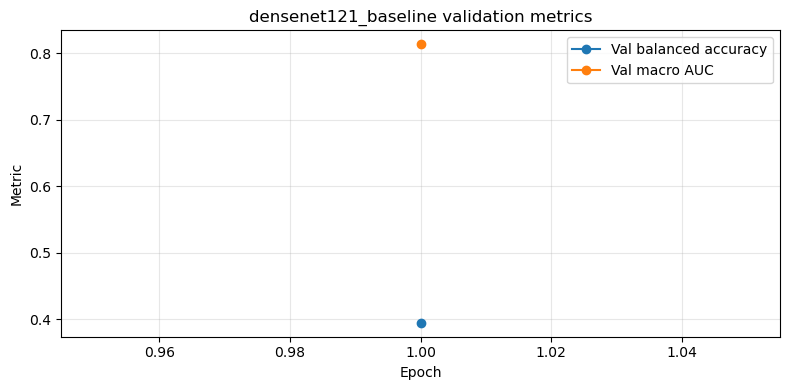

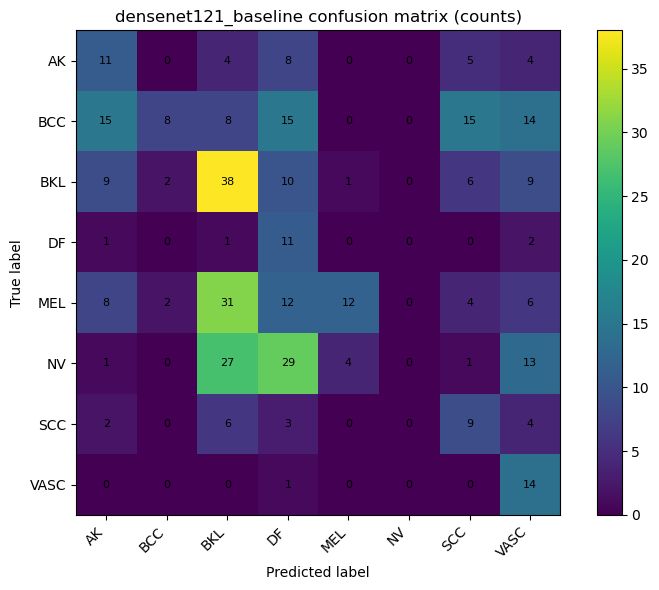

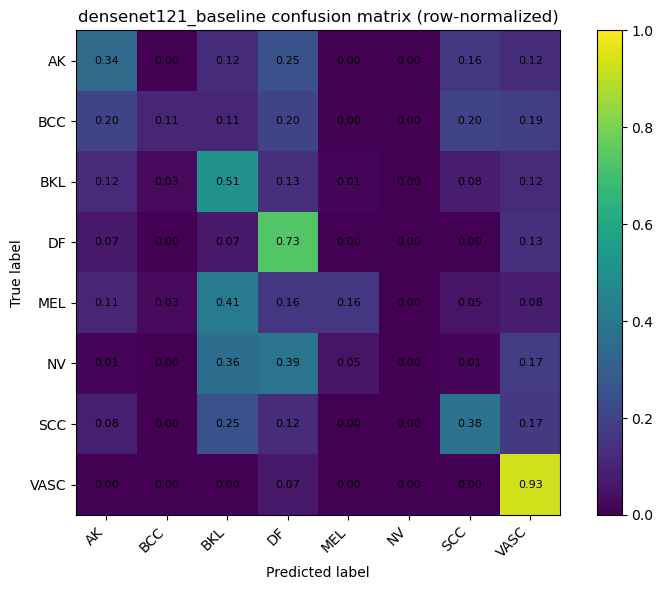

Running backbone=densenet121, stage=phase1_plus_2
Training components:
  baseline: 1239
  phase2: 1239
Combined train size: 2478
Validation size: 386
Use CutMix: False
densenet121 | phase1_plus_2 | Epoch 01 | train_size=2478 | train_loss=1.5001 | val_loss=1.1941 | val_bal_acc=0.4719 | val_macro_auc=0.8579 | epoch_time=0.84 min


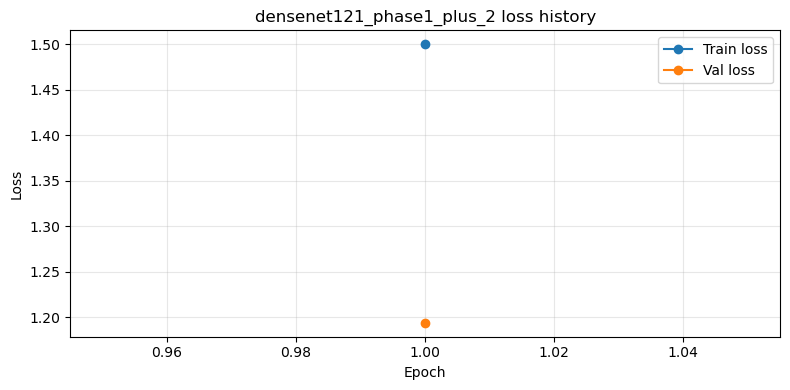

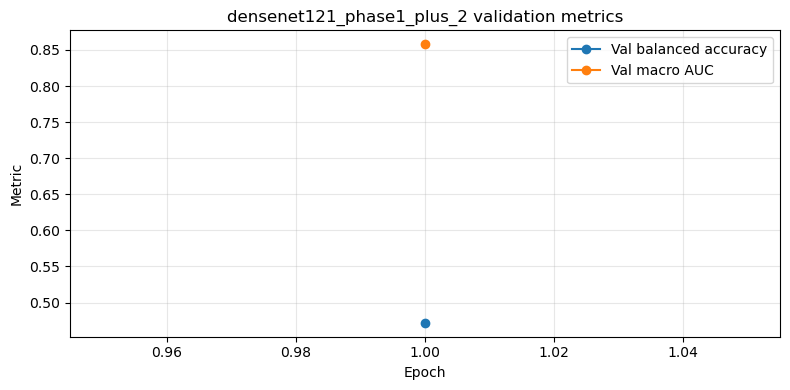

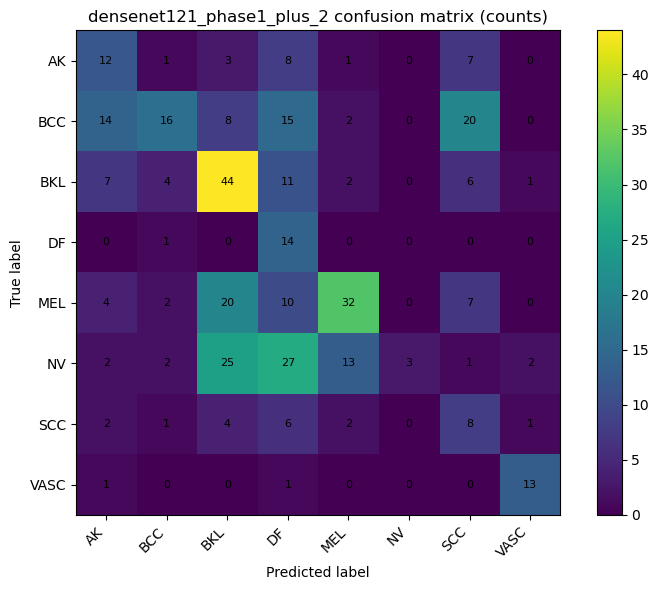

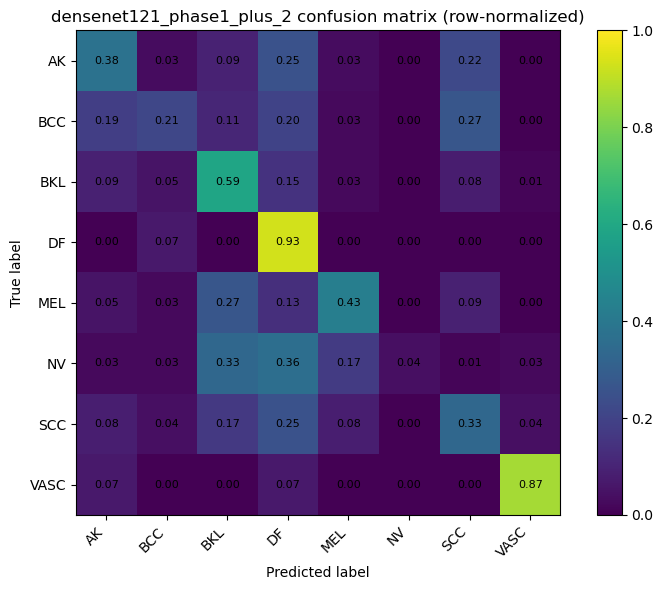

Running backbone=densenet121, stage=phase1_plus_2_plus_3
Training components:
  baseline: 1239
  phase2: 1239
  phase3: 1239
Combined train size: 3717
Validation size: 386
Use CutMix: False
densenet121 | phase1_plus_2_plus_3 | Epoch 01 | train_size=3717 | train_loss=1.3884 | val_loss=1.2016 | val_bal_acc=0.4968 | val_macro_auc=0.8615 | epoch_time=1.24 min


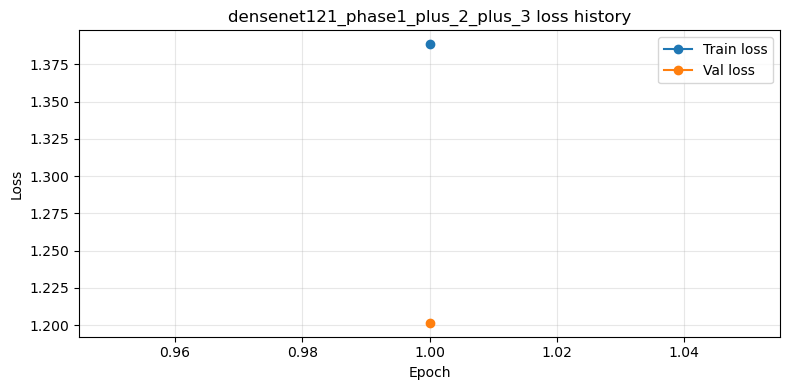

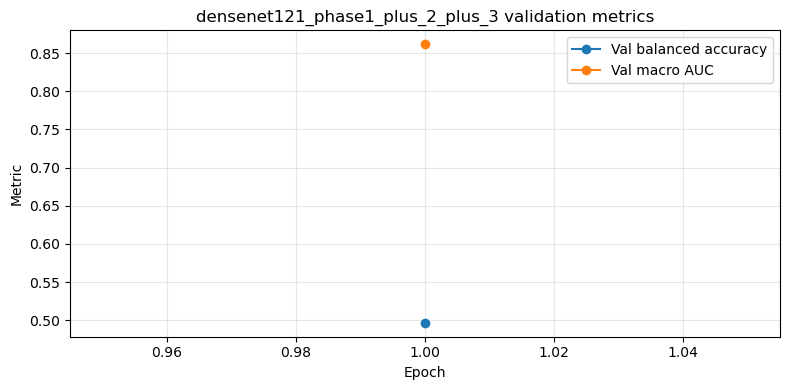

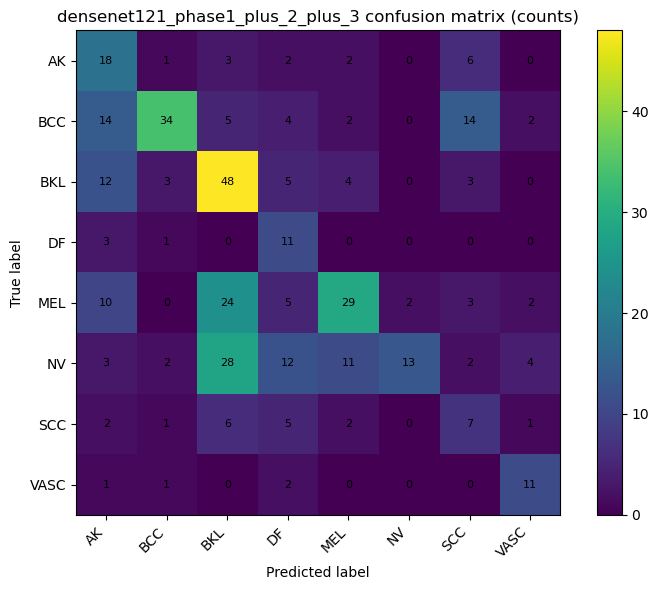

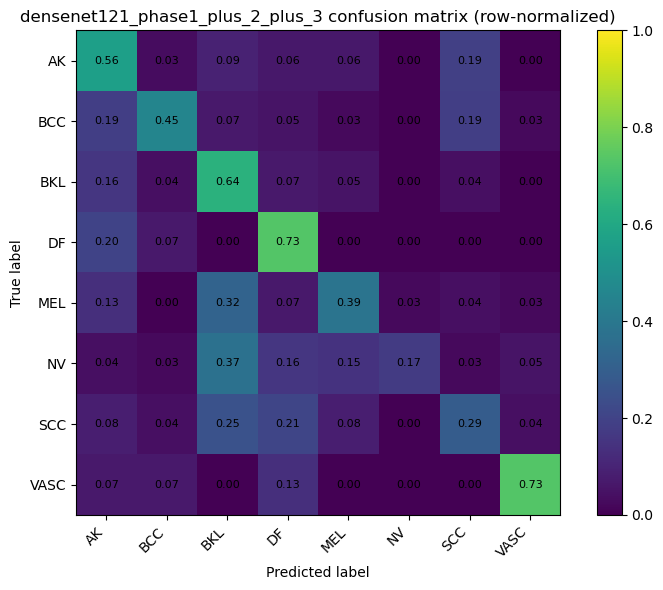

Running backbone=densenet121, stage=phase1_plus_2_plus_3_plus_4
Training components:
  baseline: 1239
  phase2: 1239
  phase3: 1239
  phase4: 1239
Combined train size: 4956
Validation size: 386
Use CutMix: True
densenet121 | phase1_plus_2_plus_3_plus_4 | Epoch 01 | train_size=4956 | train_loss=1.4948 | val_loss=1.0906 | val_bal_acc=0.5301 | val_macro_auc=0.8661 | epoch_time=1.63 min


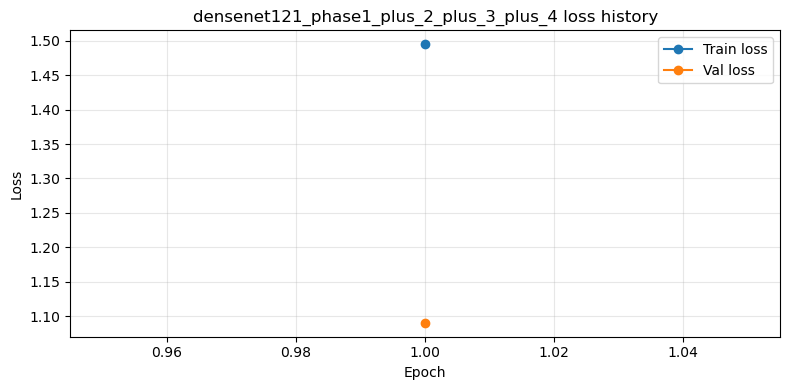

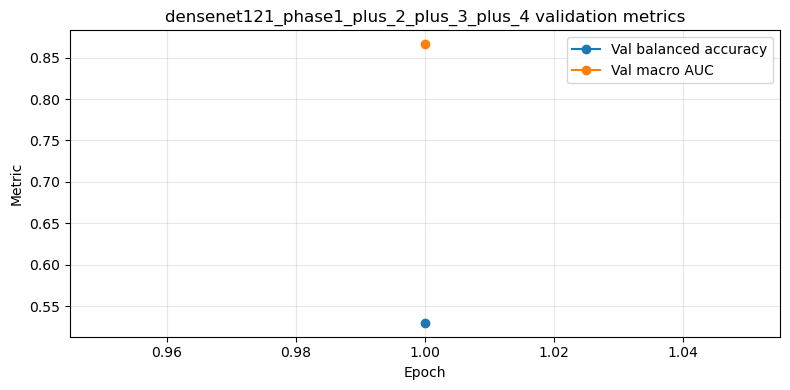

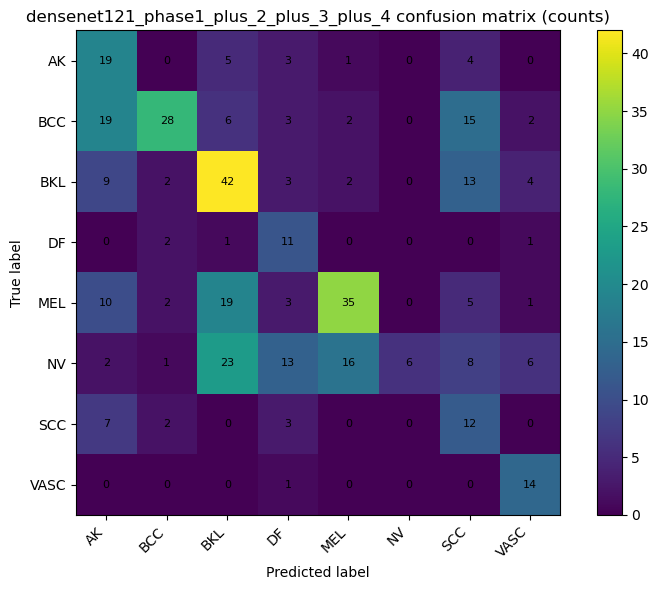

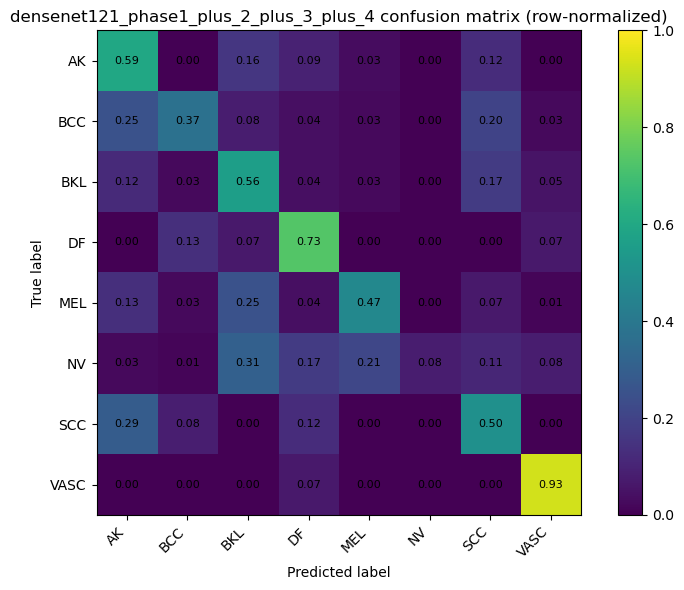

,backbone,stage,combined_train_size,val_size,use_cutmix,best_epoch,best_val_loss,best_val_balanced_accuracy,best_val_macro_auc,history_path,pred_path,report_path,checkpoint_path
0,resnet50,baseline,1239,386,False,1,1.745556,0.319219,0.724101,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
1,resnet50,phase1_plus_2,2478,386,False,1,1.425033,0.411146,0.794698,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
2,resnet50,phase1_plus_2_plus_3,3717,386,False,1,1.301634,0.463594,0.843629,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
3,resnet50,phase1_plus_2_plus_3_plus_4,4956,386,True,1,1.326905,0.441719,0.817568,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
4,efficientnet_b0,baseline,1239,386,False,1,1.781486,0.368177,0.741437,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
5,efficientnet_b0,phase1_plus_2,2478,386,False,1,1.526168,0.382083,0.782768,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
6,efficientnet_b0,phase1_plus_2_plus_3,3717,386,False,1,1.368970,0.388646,0.805232,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
7,efficientnet_b0,phase1_plus_2_plus_3_plus_4,4956,386,True,1,1.273217,0.419167,0.823379,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
8,densenet121,baseline,1239,386,False,1,1.367242,0.394844,0.813374,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
9,densenet121,phase1_plus_2,2478,386,False,1,1.194145,0.471875,0.857876,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...


Saved results to: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/metrics/ablation_smoke_comparison.csv


In [40]:
comparison_rows = []

for backbone in BACKBONES:
    for stage_name in ABLATION_STAGES:
        result = run_ablation_experiment(
            backbone=backbone,
            stage_name=stage_name,
        )
        comparison_rows.append(result)

results_df = pd.DataFrame(comparison_rows)
display(results_df)

results_out = METRIC_DIR / (
    "ablation_smoke_comparison.csv" if SMOKE_MODE else "ablation_full_comparison.csv"
)
results_df.to_csv(results_out, index=False)

print("Saved results to:", results_out)

## Backbone-wise cumulative comparison plots

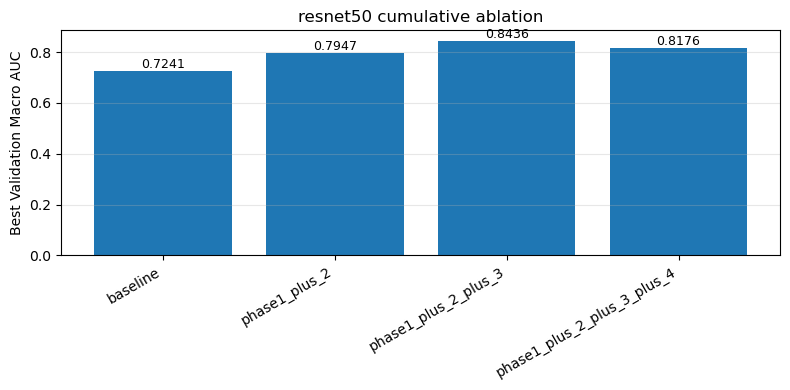

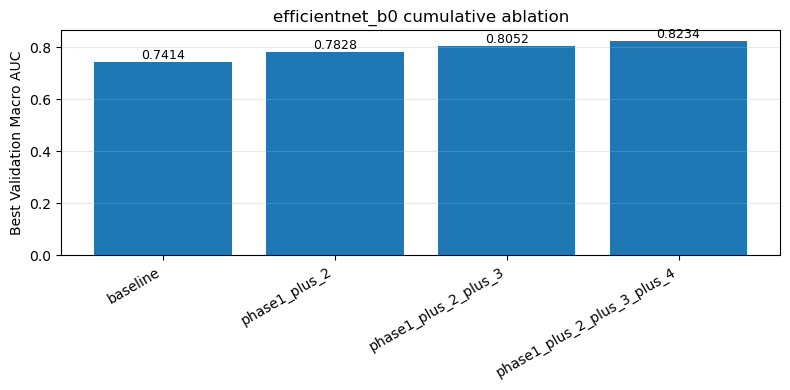

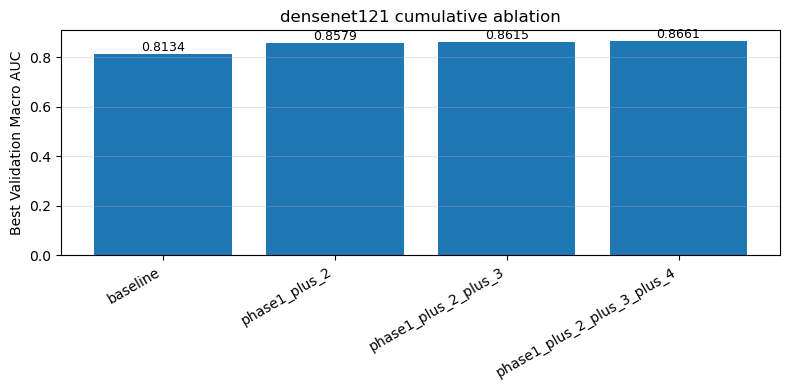

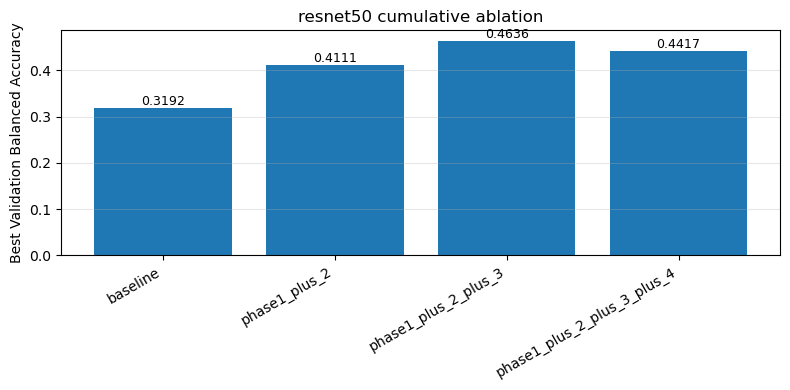

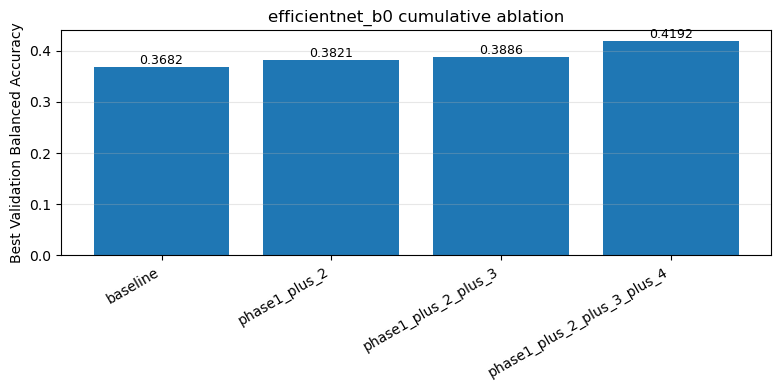

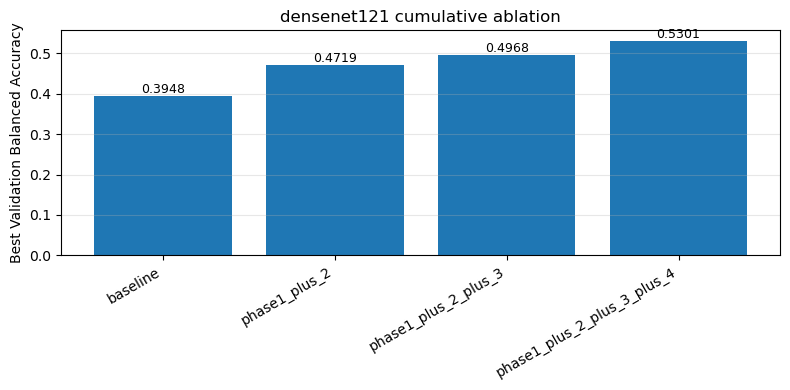

In [41]:
for metric_col, metric_label in [
    ("best_val_macro_auc", "Best Validation Macro AUC"),
    ("best_val_balanced_accuracy", "Best Validation Balanced Accuracy"),
]:
    for backbone in BACKBONES:
        subset = results_df[results_df["backbone"] == backbone].copy()
        if subset.empty:
            continue

        subset["stage"] = pd.Categorical(
            subset["stage"],
            categories=ABLATION_STAGES,
            ordered=True,
        )
        subset = subset.sort_values("stage")

        plt.figure(figsize=(8, 4))
        bars = plt.bar(subset["stage"].astype(str), subset[metric_col])
        plt.ylabel(metric_label)
        plt.title(f"{backbone} cumulative ablation")
        plt.xticks(rotation=30, ha="right")
        plt.grid(axis="y", alpha=0.3)

        for bar, value in zip(bars, subset[metric_col]):
            if pd.notna(value):
                plt.text(
                    bar.get_x() + bar.get_width() / 2,
                    value,
                    f"{value:.4f}",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                )

        plt.tight_layout()
        out_name = f"{backbone}_{metric_col}_ablation.png"
        plt.savefig(FIG_DIR / out_name, dpi=200, bbox_inches="tight")
        plt.show()

## Cross-backbone summary plots

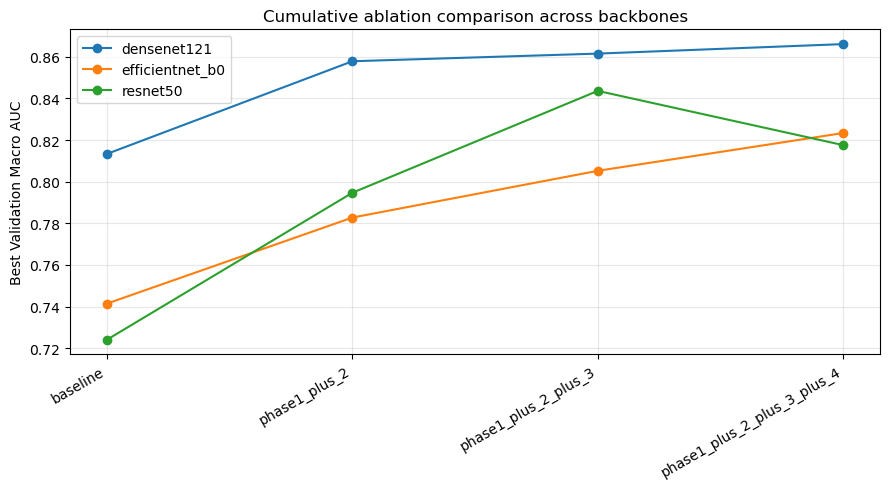

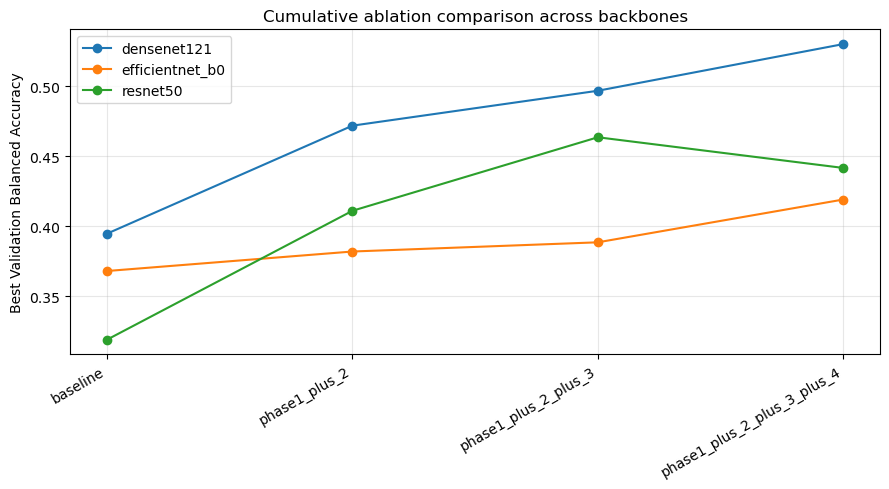

In [42]:
for metric_col, metric_label in [
    ("best_val_macro_auc", "Best Validation Macro AUC"),
    ("best_val_balanced_accuracy", "Best Validation Balanced Accuracy"),
]:
    pivot_df = results_df.pivot(
        index="stage",
        columns="backbone",
        values=metric_col,
    ).reindex(ABLATION_STAGES)

    plt.figure(figsize=(9, 5))
    for backbone in pivot_df.columns:
        plt.plot(pivot_df.index, pivot_df[backbone], marker="o", label=backbone)

    plt.ylabel(metric_label)
    plt.title(f"Cumulative ablation comparison across backbones")
    plt.xticks(rotation=30, ha="right")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    out_name = f"cross_backbone_{metric_col}_ablation.png"
    plt.savefig(FIG_DIR / out_name, dpi=200, bbox_inches="tight")
    plt.show()

## Best-stage summary by backbone

In [43]:
best_by_auc = (
    results_df.sort_values(
        by=["best_val_macro_auc", "best_val_balanced_accuracy"],
        ascending=False,
    )
    .groupby("backbone", as_index=False)
    .first()
)

display(best_by_auc)

best_by_auc_out = METRIC_DIR / (
    "ablation_best_stage_by_backbone_smoke.csv" if SMOKE_MODE else "ablation_best_stage_by_backbone_full.csv"
)
best_by_auc.to_csv(best_by_auc_out, index=False)

print("Saved best-stage summary to:", best_by_auc_out)

,backbone,stage,combined_train_size,val_size,use_cutmix,best_epoch,best_val_loss,best_val_balanced_accuracy,best_val_macro_auc,history_path,pred_path,report_path,checkpoint_path
0,densenet121,phase1_plus_2_plus_3_plus_4,4956,386,True,1,1.090611,0.530052,0.866109,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
1,efficientnet_b0,phase1_plus_2_plus_3_plus_4,4956,386,True,1,1.273217,0.419167,0.823379,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
2,resnet50,phase1_plus_2_plus_3,3717,386,False,1,1.301634,0.463594,0.843629,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...


Saved best-stage summary to: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/metrics/ablation_best_stage_by_backbone_smoke.csv


## Notes

This notebook is intended to answer a different question than Notebook 03.

- Notebook 03 asks whether each augmentation phase helps on its own.
- Notebook 04 asks whether performance improves as augmentation phases are added cumulatively.

The cumulative design here keeps the baseline data present at every stage and adds stage-specific augmented copies progressively:
- baseline
- baseline + phase2
- baseline + phase2 + phase3
- baseline + phase2 + phase3 + phase4

Validation remains non-augmented throughout.

Phase 4 uses RandomResizedCrop in the transform pipeline and CutMix in the training loop.

Once full runs are completed, the saved outputs from this notebook should support:
- a cumulative ablation results table
- backbone-wise performance trend plots
- confusion matrices for selected best runs
- classification-report discussion in the final written report

## Full-run override and rerun block

The notebook above was validated in smoke mode. The following cells override smoke-mode settings for a full cumulative ablation run without changing the earlier working notebook setup.

This block:
- switches from smoke subsets to the full processed ISIC 2019 train and validation splits
- allows the full-run epoch count to be adjusted from one place
- re-saves the experiment config to reflect the full run
- reruns the cumulative ablation workflow and writes full-run outputs

In [46]:
# ==========================================
# CLEAR PRIOR IN-MEMORY RESULTS
# ==========================================

comparison_rows = []
results_df = pd.DataFrame()

print("Cleared prior in-memory comparison objects.")

Cleared prior in-memory comparison objects.


In [47]:
# =========================
# FULL-RUN OVERRIDE CONTROL
# =========================

RUN_FULL_EXPERIMENT = True
FULL_RUN_EPOCHS = 5   # change this later to 8, 10, etc. if desired

if RUN_FULL_EXPERIMENT:
    SMOKE_MODE = False
    EPOCHS = FULL_RUN_EPOCHS

    train_run_df = train_df.copy()
    val_run_df = val_df.copy()

    print("Full experiment override is ON")
    print("SMOKE_MODE:", SMOKE_MODE)
    print("EPOCHS:", EPOCHS)
    print("train_run_df shape:", train_run_df.shape)
    print("val_run_df shape:", val_run_df.shape)
else:
    print("RUN_FULL_EXPERIMENT is False. No override applied.")

Full experiment override is ON
SMOKE_MODE: False
EPOCHS: 5
train_run_df shape: (21531, 22)
val_run_df shape: (3800, 22)


In [48]:
# ==========================================
# RESAVE CONFIG SO OUTPUTS MATCH THIS RUN
# ==========================================

EXPERIMENT_CONFIG = {
    "notebook": "04_ablation_study",
    "seed": EXPERIMENT_SEED,
    "smoke_mode": SMOKE_MODE,
    "ablation_stages": ABLATION_STAGES,
    "backbones": BACKBONES,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "freeze_features": FREEZE_FEATURES,
    "run_full_experiment": RUN_FULL_EXPERIMENT,
    "full_run_epochs": FULL_RUN_EPOCHS if RUN_FULL_EXPERIMENT else None,
    "train_rows": int(len(train_run_df)),
    "val_rows": int(len(val_run_df)),
}

config_path = CONFIG_DIR / ("smoke_config.json" if SMOKE_MODE else "full_config.json")

with open(config_path, "w") as f:
    json.dump(EXPERIMENT_CONFIG, f, indent=2)

print("Updated config saved to:", config_path)
print(json.dumps(EXPERIMENT_CONFIG, indent=2))

Updated config saved to: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/outputs/configs/04_ablation_study/full_config.json
{
  "notebook": "04_ablation_study",
  "seed": 42,
  "smoke_mode": false,
  "ablation_stages": [
    "baseline",
    "phase1_plus_2",
    "phase1_plus_2_plus_3",
    "phase1_plus_2_plus_3_plus_4"
  ],
  "backbones": [
    "resnet50",
    "efficientnet_b0",
    "densenet121"
  ],
  "image_size": 224,
  "batch_size": 32,
  "epochs": 5,
  "learning_rate": 0.0001,
  "weight_decay": 0.0001,
  "freeze_features": false,
  "run_full_experiment": true,
  "full_run_epochs": 5,
  "train_rows": 21531,
  "val_rows": 3800
}


Running backbone=resnet50, stage=baseline
Training components:
  baseline: 21531
Combined train size: 21531
Validation size: 3800
Use CutMix: False
resnet50 | baseline | Epoch 01 | train_size=21531 | train_loss=1.3277 | val_loss=0.9875 | val_bal_acc=0.6420 | val_macro_auc=0.9300 | epoch_time=7.07 min
resnet50 | baseline | Epoch 02 | train_size=21531 | train_loss=0.7983 | val_loss=0.8713 | val_bal_acc=0.6991 | val_macro_auc=0.9436 | epoch_time=6.84 min
resnet50 | baseline | Epoch 03 | train_size=21531 | train_loss=0.5165 | val_loss=0.8434 | val_bal_acc=0.7244 | val_macro_auc=0.9508 | epoch_time=6.75 min
resnet50 | baseline | Epoch 04 | train_size=21531 | train_loss=0.3399 | val_loss=0.8162 | val_bal_acc=0.7487 | val_macro_auc=0.9540 | epoch_time=6.80 min
resnet50 | baseline | Epoch 05 | train_size=21531 | train_loss=0.2298 | val_loss=0.9644 | val_bal_acc=0.7283 | val_macro_auc=0.9564 | epoch_time=6.85 min


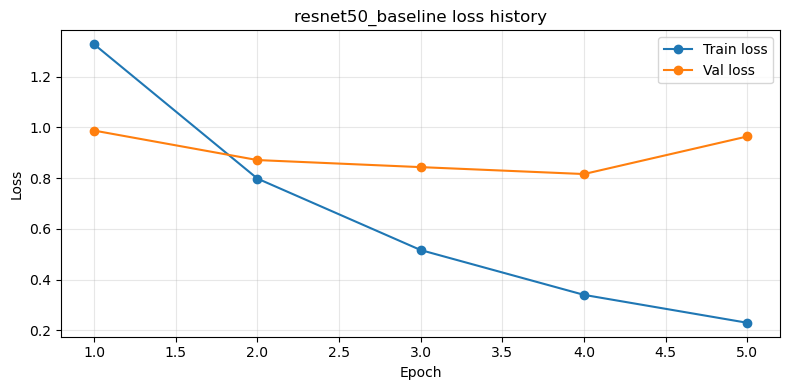

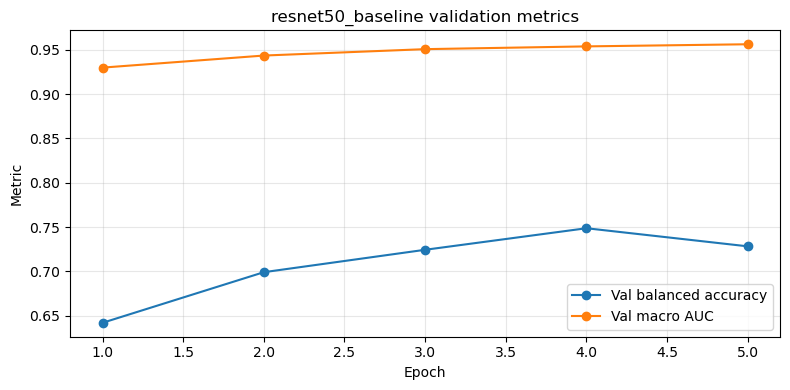

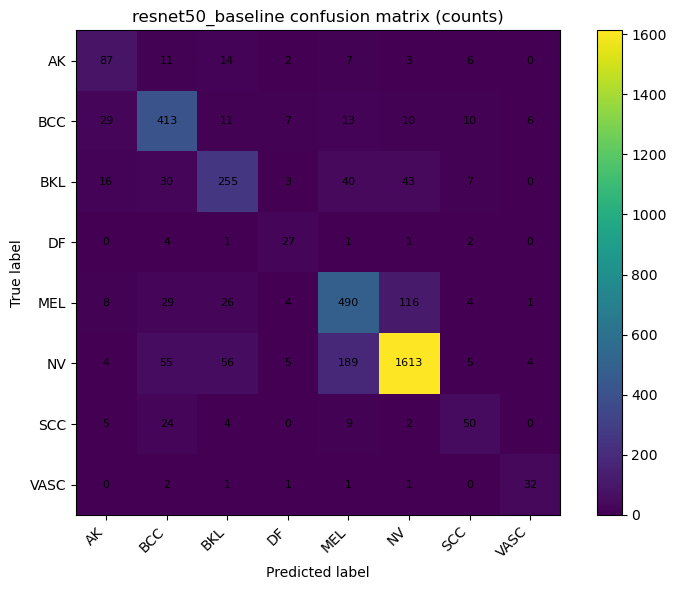

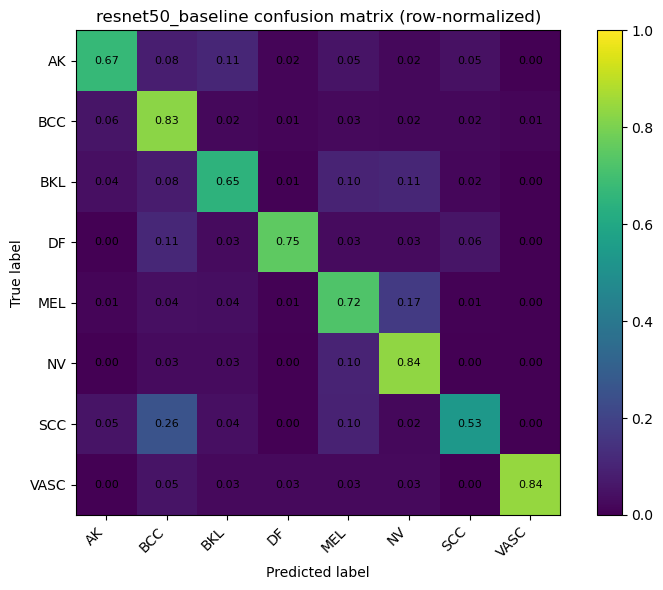

Running backbone=resnet50, stage=phase1_plus_2
Training components:
  baseline: 21531
  phase2: 21531
Combined train size: 43062
Validation size: 3800
Use CutMix: False
resnet50 | phase1_plus_2 | Epoch 01 | train_size=43062 | train_loss=1.0831 | val_loss=0.8542 | val_bal_acc=0.6944 | val_macro_auc=0.9468 | epoch_time=13.69 min
resnet50 | phase1_plus_2 | Epoch 02 | train_size=43062 | train_loss=0.5894 | val_loss=0.7774 | val_bal_acc=0.7409 | val_macro_auc=0.9543 | epoch_time=13.56 min
resnet50 | phase1_plus_2 | Epoch 03 | train_size=43062 | train_loss=0.4104 | val_loss=0.7384 | val_bal_acc=0.7685 | val_macro_auc=0.9661 | epoch_time=13.53 min
resnet50 | phase1_plus_2 | Epoch 04 | train_size=43062 | train_loss=0.3127 | val_loss=0.7482 | val_bal_acc=0.7614 | val_macro_auc=0.9638 | epoch_time=13.60 min
resnet50 | phase1_plus_2 | Epoch 05 | train_size=43062 | train_loss=0.2466 | val_loss=0.7636 | val_bal_acc=0.7639 | val_macro_auc=0.9670 | epoch_time=13.18 min


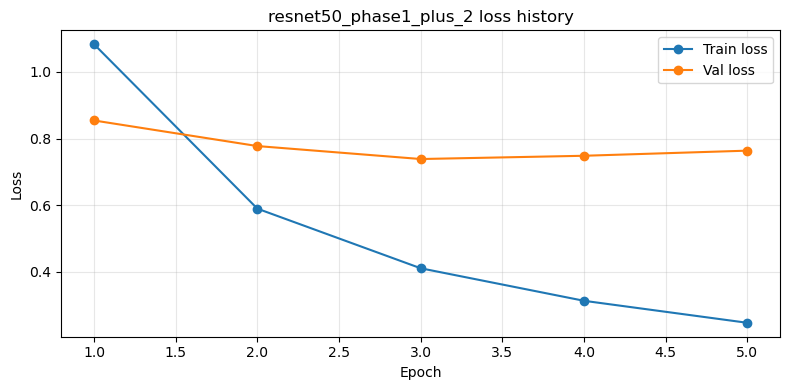

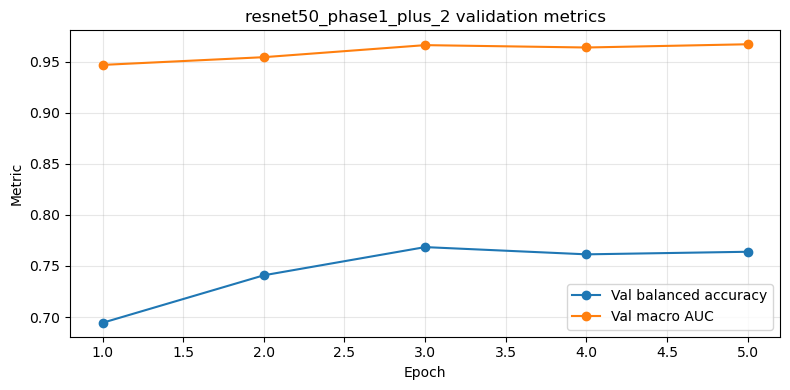

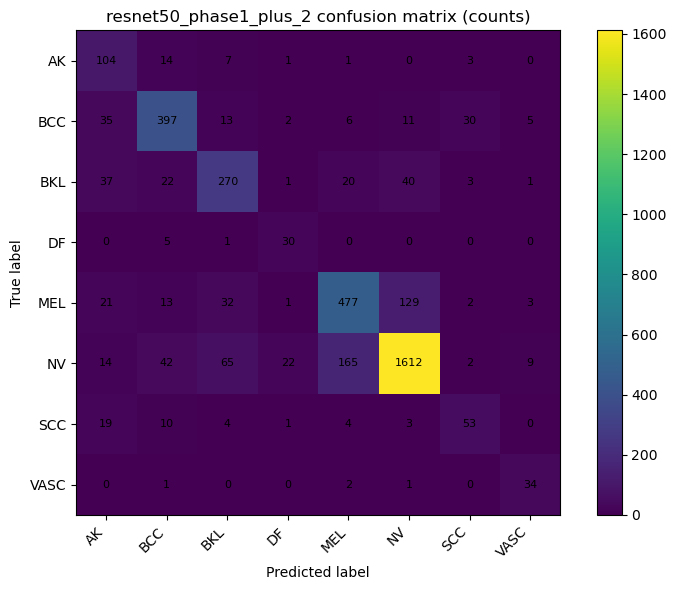

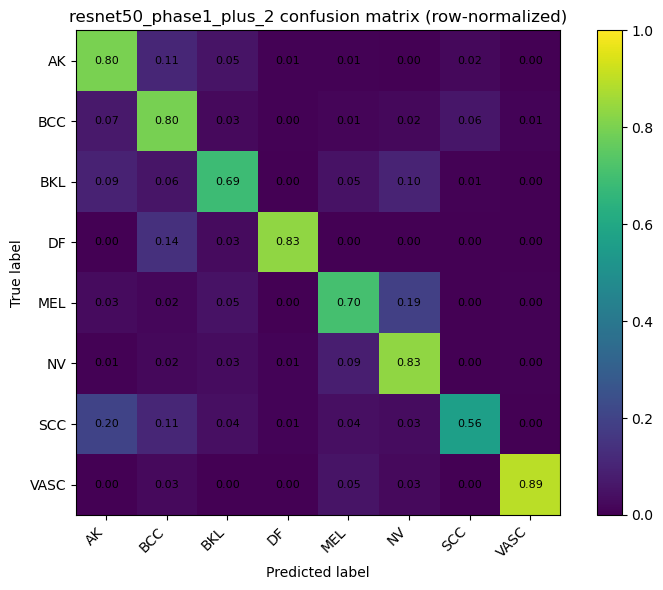

Running backbone=resnet50, stage=phase1_plus_2_plus_3
Training components:
  baseline: 21531
  phase2: 21531
  phase3: 21531
Combined train size: 64593
Validation size: 3800
Use CutMix: False
resnet50 | phase1_plus_2_plus_3 | Epoch 01 | train_size=64593 | train_loss=1.0862 | val_loss=0.8370 | val_bal_acc=0.7245 | val_macro_auc=0.9405 | epoch_time=19.79 min
resnet50 | phase1_plus_2_plus_3 | Epoch 02 | train_size=64593 | train_loss=0.6195 | val_loss=0.7165 | val_bal_acc=0.7607 | val_macro_auc=0.9549 | epoch_time=19.82 min
resnet50 | phase1_plus_2_plus_3 | Epoch 03 | train_size=64593 | train_loss=0.4281 | val_loss=0.6541 | val_bal_acc=0.7922 | val_macro_auc=0.9661 | epoch_time=19.71 min


In [ ]:
# ==========================================
# RUN FULL CUMULATIVE ABLATION EXPERIMENTS
# ==========================================

comparison_rows = []

for backbone in BACKBONES:
    for stage_name in ABLATION_STAGES:
        result = run_ablation_experiment(
            backbone=backbone,
            stage_name=stage_name,
        )
        comparison_rows.append(result)

results_df = pd.DataFrame(comparison_rows)
display(results_df)

results_out = METRIC_DIR / (
    "ablation_smoke_comparison.csv" if SMOKE_MODE else "ablation_full_comparison.csv"
)
results_df.to_csv(results_out, index=False)

print("Saved results to:", results_out)

In [ ]:
# ==========================================
# BACKBONE-WISE CUMULATIVE COMPARISON PLOTS
# ==========================================

for metric_col, metric_label in [
    ("best_val_macro_auc", "Best Validation Macro AUC"),
    ("best_val_balanced_accuracy", "Best Validation Balanced Accuracy"),
]:
    for backbone in BACKBONES:
        subset = results_df[results_df["backbone"] == backbone].copy()
        if subset.empty:
            continue

        subset["stage"] = pd.Categorical(
            subset["stage"],
            categories=ABLATION_STAGES,
            ordered=True,
        )
        subset = subset.sort_values("stage")

        plt.figure(figsize=(8, 4))
        bars = plt.bar(subset["stage"].astype(str), subset[metric_col])
        plt.ylabel(metric_label)
        plt.title(f"{backbone} cumulative ablation")
        plt.xticks(rotation=30, ha="right")
        plt.grid(axis="y", alpha=0.3)

        for bar, value in zip(bars, subset[metric_col]):
            if pd.notna(value):
                plt.text(
                    bar.get_x() + bar.get_width() / 2,
                    value,
                    f"{value:.4f}",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                )

        plt.tight_layout()
        out_name = f"{backbone}_{metric_col}_ablation.png"
        plt.savefig(FIG_DIR / out_name, dpi=200, bbox_inches="tight")
        plt.show()

In [ ]:
# ==========================================
# CROSS-BACKBONE SUMMARY PLOTS
# ==========================================

for metric_col, metric_label in [
    ("best_val_macro_auc", "Best Validation Macro AUC"),
    ("best_val_balanced_accuracy", "Best Validation Balanced Accuracy"),
]:
    pivot_df = results_df.pivot(
        index="stage",
        columns="backbone",
        values=metric_col,
    ).reindex(ABLATION_STAGES)

    plt.figure(figsize=(9, 5))
    for backbone in pivot_df.columns:
        plt.plot(pivot_df.index, pivot_df[backbone], marker="o", label=backbone)

    plt.ylabel(metric_label)
    plt.title(f"Cumulative ablation comparison across backbones")
    plt.xticks(rotation=30, ha="right")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    out_name = f"cross_backbone_{metric_col}_ablation.png"
    plt.savefig(FIG_DIR / out_name, dpi=200, bbox_inches="tight")
    plt.show()

In [ ]:
# ==========================================
# BEST-STAGE SUMMARY BY BACKBONE
# ==========================================

best_by_auc = (
    results_df.sort_values(
        by=["best_val_macro_auc", "best_val_balanced_accuracy"],
        ascending=False,
    )
    .groupby("backbone", as_index=False)
    .first()
)

display(best_by_auc)

best_by_auc_out = METRIC_DIR / (
    "ablation_best_stage_by_backbone_smoke.csv"
    if SMOKE_MODE else
    "ablation_best_stage_by_backbone_full.csv"
)
best_by_auc.to_csv(best_by_auc_out, index=False)

print("Saved best-stage summary to:", best_by_auc_out)